
# Explicabilidad de redes neuronales para señales de tráfico

**Autores:** Alejandra Llord, Carolina Romero

**Dataset:** GTSRB – German Traffic Sign Recognition Benchmark  
**Modelos:** CNN Supersencilla · CNN Simple · CNN Compleja  
**Métodos XAI:** Grad-CAM · Integrated Gradients · Oclusión · LIME

---

## Resumen

Los coches autónomos necesitan reconocer señales de tráfico de forma fiable. Pero que el modelo acierte no es suficiente: hay que saber por qué acierta. Si una red aprende a clasificar un límite de velocidad porque detecta el borde rojo y no el número, puede suponer un problema.

En este trabajo entrenamos tres redes convolucionales con 12 clases del dataset GTSRB: una supersencilla, una simple y una compleja. Luego usamos cuatro métodos de IA explicable (Grad-CAM, Integrated Gradients, Oclusión y LIME) para ver qué zonas de cada imagen usa cada modelo al tomar su decisión. Comparar los tres modelos nos permite ver cómo evoluciona el aprendizaje con la capacidad de la red. Por último, diseñamos perturbaciones propias (tapar el número, tapar el borde, añadir ruido...) para comprobar directamente qué información necesita cada modelo.

---

## Preguntas Preliminares

1. ¿El modelo mira la parte correcta de cada señal?
2. En límites de velocidad, ¿mira el número o solo el borde rojo?
3. En la señal de Stop, ¿mira la palabra, la forma o el color?
4. En señales triangulares, ¿mira el símbolo interno o solo el triángulo?
5. ¿Coinciden los cuatro métodos XAI entre sí?
6. ¿Cómo cambia la explicación según la capacidad del modelo (Supersencilla vs Simple vs Compleja)?

## Hipótesis

- La CNN Supersencilla probablemente se fijará en detalles muy generales, como el borde rojo o la forma de la señal, en lugar de fijarse en el número o el símbolo interior.

- La CNN Simple puede aprender algo más de información, pero todavía puede depender bastante del borde o de la forma general.

- La CNN Compleja debería aprender mejor los elementos importantes de cada señal, como los números, los símbolos interiores y la forma concreta.


In [ ]:
# Instalar dependencias (ejecutar solo si hace falta)
!pip install tensorflow lime scikit-learn matplotlib seaborn numpy pillow tqdm pandas scipy -q

In [ ]:
import os
import io
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from lime import lime_image
from skimage.segmentation import mark_boundaries

#  Configuración global
IMG_SIZE   = 64
SEED       = 42
BATCH_SIZE = 64
EPOCHS     = 20
EPOCHS_SUPER_SENCILLA = 7

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Ruta al zip con los datos (en la misma carpeta que el notebook)
ZIP_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'archive.zip')
if not os.path.exists(ZIP_PATH):
    ZIP_PATH = 'archive.zip'   # fallback por si el notebook se ejecuta desde otro directorio

# 12 clases seleccionadas del GTSRB (ID original → nombre)
SELECTED = {
    0:  'Límite 20',
    1:  'Límite 30',
    2:  'Límite 50',
    5:  'Límite 80',
    13: 'Ceda el paso',
    14: 'Stop',
    17: 'Prohibido paso',
    18: 'Precaución general',
    25: 'Obras',
    27: 'Peatones',
    33: 'Girar derecha',
    34: 'Girar izquierda',
}

CLASS_IDS   = sorted(SELECTED.keys())
CLASS_NAMES = [SELECTED[k] for k in CLASS_IDS]
NUM_CLASSES = len(CLASS_IDS)
ID_TO_IDX   = {cid: i for i, cid in enumerate(CLASS_IDS)}

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {bool(tf.config.list_physical_devices("GPU"))}')
print(f'Zip de datos: {ZIP_PATH}  →  existe: {os.path.exists(ZIP_PATH)}')
print(f'Número de clases: {NUM_CLASSES}')
print('Clases:', CLASS_NAMES)

TensorFlow: 2.21.0
GPU disponible: False
Zip de datos: c:\IA\XIA_Alejandra_Carolina\archive.zip  →  existe: True
Número de clases: 12
Clases: ['Límite 20', 'Límite 30', 'Límite 50', 'Límite 80', 'Ceda el paso', 'Stop', 'Prohibido paso', 'Precaución general', 'Obras', 'Peatones', 'Girar derecha', 'Girar izquierda']


---
## 1. Datos: GTSRB

El GTSRB (German Traffic Sign Recognition Benchmark) contiene más de 50 000 fotos de señales de tráfico alemanas tomadas en carretera real, distribuidas en 43 clases. Las imágenes varían mucho en tamaño, luz y calidad.

Nosotras usamos 12 clases que nos permiten estudiar diferencias claves:
- Por número: Límite 20, 30, 50, 80 → misma forma y color, solo cambia el número.
- Por forma: Stop (octógono), Ceda el paso (triángulo invertido), circulares.
- Por color: Stop (rojo), Ceda el paso (rojo y blanco), Precaución (amarillo).
- Por símbolo: Peatones, Obras, Girar derecha/izquierda.

### Fuente de los datos
El zip tiene esta estructura:
```
archive.zip
├── Train.csv      → lista de imágenes de entrenamiento y su clase
├── Test.csv       → lista de imágenes de prueba y su información
├── Train/         → carpeta con las imágenes de entrenamiento separadas por clase
│   ├── 0/         → imágenes de la clase 0
│   ├── 1/         → imágenes de la clase 1
│   └── ...
└── Test/          → carpeta con las imágenes de prueba
```

### Preprocesamiento
- Leemos cada imagen desde el zip y la convertimos a RGB.
- Redimensionamos a 64×64 píxeles.
- Normalizamos los valores al rango [0, 1] dividiendo entre 255.
- Dividimos en train / validación / test (85% / 15% del train original y el test que viene separado en el csv).

In [ ]:
def load_from_zip(zip_path, csv_name, selected_ids, id_to_idx, img_size=IMG_SIZE):
    """
    Lee imágenes y etiquetas directamente desde el zip usando el CSV de metadatos.

    Estructura esperada en el zip:
      - Train.csv / Test.csv  →  columnas: Width, Height, Roi.X1, Roi.Y1,
                                           Roi.X2, Roi.Y2, ClassId, Path
      - Imágenes en Train/<ClassId>/<nombre>.png  o  Test/<nombre>.png
    """
    with zipfile.ZipFile(zip_path, 'r') as z:

        # 1. Leer el CSV desde dentro del zip
        with z.open(csv_name) as f:
            df = pd.read_csv(f)

        # 2. Filtrar solo las 12 clases que nos interesan
        df = df[df['ClassId'].isin(selected_ids)].reset_index(drop=True)
        print(f'  {csv_name}: {len(df)} imágenes de las clases seleccionadas')

        # 3. Cargar cada imagen
        images, labels = [], []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f'  Leyendo {csv_name}'):
            img_path = row['Path']     # ej: "Train/1/00001_00000_00000.png"
            class_id = int(row['ClassId'])

            with z.open(img_path) as img_file:
                img = Image.open(io.BytesIO(img_file.read())).convert('RGB')

            img = img.resize((img_size, img_size), Image.BILINEAR)
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(id_to_idx[class_id])

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


print(f'Cargando datos desde {ZIP_PATH} ...\n')

X_all,  y_all  = load_from_zip(ZIP_PATH, 'Train.csv', CLASS_IDS, ID_TO_IDX)
print()
X_test, y_test = load_from_zip(ZIP_PATH, 'Test.csv',  CLASS_IDS, ID_TO_IDX)

# Split train → train + validación (estratificado por clase)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all
)

print(f'\nTrain : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Rango de valores: [{X_train.min():.2f}, {X_train.max():.2f}]')

Cargando datos desde c:\IA\XIA_Alejandra_Carolina\archive.zip ...

  Train.csv: 14639 imágenes de las clases seleccionadas


  Leyendo Train.csv: 100%|██████████| 14639/14639 [00:06<00:00, 2249.39it/s]



  Test.csv: 4770 imágenes de las clases seleccionadas


  Leyendo Test.csv: 100%|██████████| 4770/4770 [00:03<00:00, 1466.43it/s]



Train : (12443, 64, 64, 3)  |  Val: (2196, 64, 64, 3)  |  Test: (4770, 64, 64, 3)
Rango de valores: [0.00, 1.00]


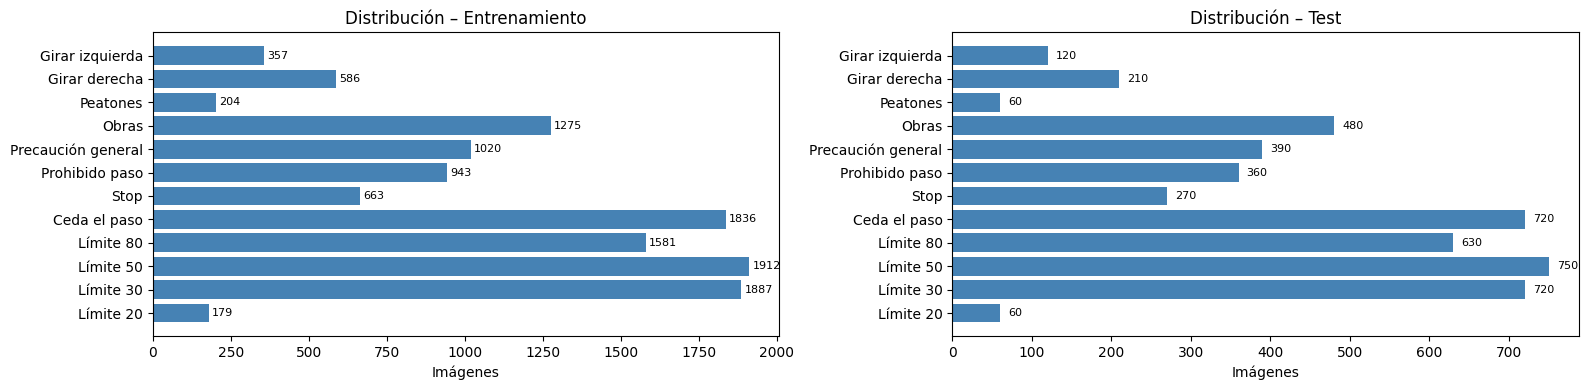

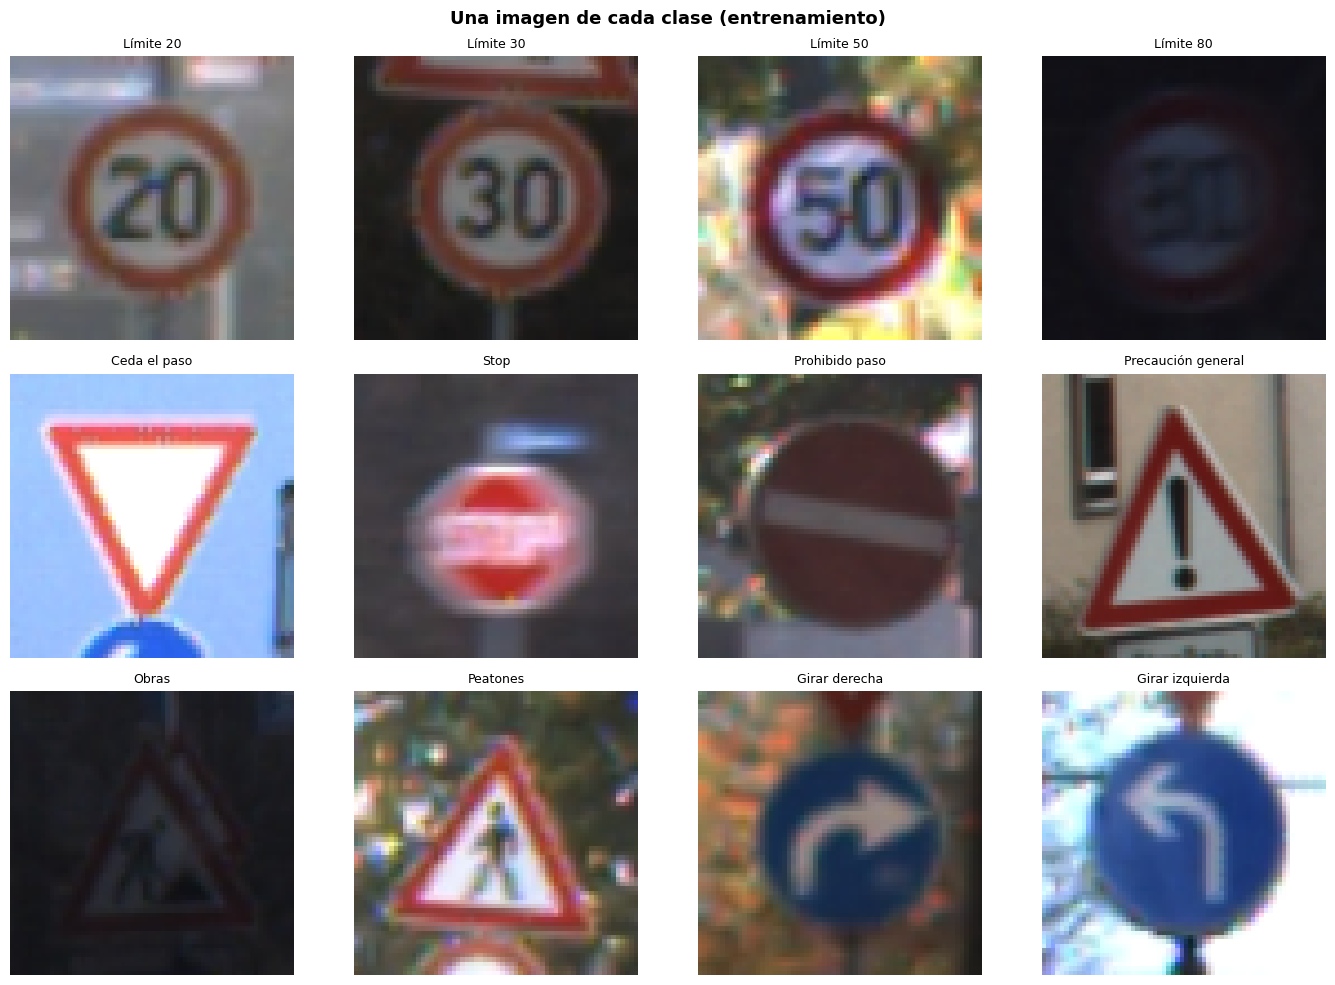

In [ ]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, split, name in [
    (axes[0], y_train, 'Entrenamiento'),
    (axes[1], y_test,  'Test')
]:
    counts = [np.sum(split == i) for i in range(NUM_CLASSES)]
    ax.barh(CLASS_NAMES, counts, color='steelblue')
    ax.set_xlabel('Imágenes')
    ax.set_title(f'Distribución – {name}')
    for j, c in enumerate(counts):
        ax.text(c + 10, j, str(c), va='center', fontsize=8)

plt.tight_layout()
plt.show()

#  Muestras por clase
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    idxs = np.where(y_train == i)[0]
    sample_idx = np.random.choice(idxs, 1)[0]
    ax.imshow(X_train[sample_idx])
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Una imagen de cada clase (entrenamiento)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Modelos CNN

Entrenamos tres modelos con los mismos datos, pero con distinta arquitectura. La diferencia de complejidad nos va a permitir estudiar cómo la capacidad del modelo afecta no solo al accuracy, sino a qué características aprende y cómo se refleja eso en las explicaciones XAI.

- La CNN Supersencilla es el más básico: un único bloque convolucional con 16 filtros y un MaxPooling muy agresivo (4×4) que destruye el detalle espacial fino.

- La CNN Simple es un punto intermedio con dos bloques convolucionales. Representa el tipo de red que funciona razonablemente bien para muchas tareas de clasificación de imágenes.
- La CNN Compleja tiene tres bloques convolucionales, normalización por lotes (Batch Normalization), regularización con Dropout y usa GlobalAveragePooling. Es la más potente y debería aprender representaciones más ricas.

Al comparar las explicaciones de los tres modelos respondemos: ¿Qué aprende un modelo según su capacidad? ¿Los modelos más potentes miran las zonas semánticamente correctas, o todos usan los mismos atajos visuales?

### 2.1 CNN Supersencilla

La red más simple posible: un único bloque convolucional de solo 16 filtros seguido de un MaxPooling muy extremo (4×4) que reduce la representación espacial a 16×16 píxeles, eliminando casi todo el detalle fino. Sin Dropout ni BatchNormalization, la red aprende rápido las características más gruesas (formas generales y colores dominantes) pero no tiene capacidad para detectar detalles pequeños como los dígitos de las señales de velocidad o los símbolos dentro de los triángulos.

```
Entrada (64×64×3)
  → Conv2D(16) → MaxPool(4×4)   ← pooling extremo, los dígitos quedan irreconocibles
  → Flatten → Dense(64)
  → Softmax (12 clases)
```

In [ ]:
def build_supersimple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3,3), padding='same', activation='relu', name='ss_conv1'),
        layers.MaxPooling2D((4,4), name='ss_pool1'),   # pooling agresivo: destruye el detalle fino
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        # sin Dropout ni regularización → aprende atajos rápidamente
        layers.Dense(num_classes, activation='softmax', name='predictions'),
    ], name='CNN_Supersencilla')
    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

supersimple_model = build_supersimple_cnn()
supersimple_model.summary()

Model: "CNN_Supersencilla"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ss_conv1 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ss_pool1 (MaxPooling2D)         │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,436 (1.00 MB)

 Trainable params: 263,436 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9940 - loss: 0.0317 - val_accuracy: 0.9772 - val_loss: 0.0797 - learning_rate: 0.0010
Epoch 2/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9965 - loss: 0.0193 - val_accuracy: 0.9722 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 3/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9961 - loss: 0.0184 - val_accuracy: 0.9631 - val_loss: 0.1291 - learning_rate: 0.0010
Epoch 4/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9946 - loss: 0.0210 - val_accuracy: 0.9522 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 5/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9961 - loss: 0.0211 - val_accuracy: 0.9813 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 6/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9980 - loss: 0.0113 - val_accuracy: 0.9740 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 7/7
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9972 - loss: 0.0125 - 

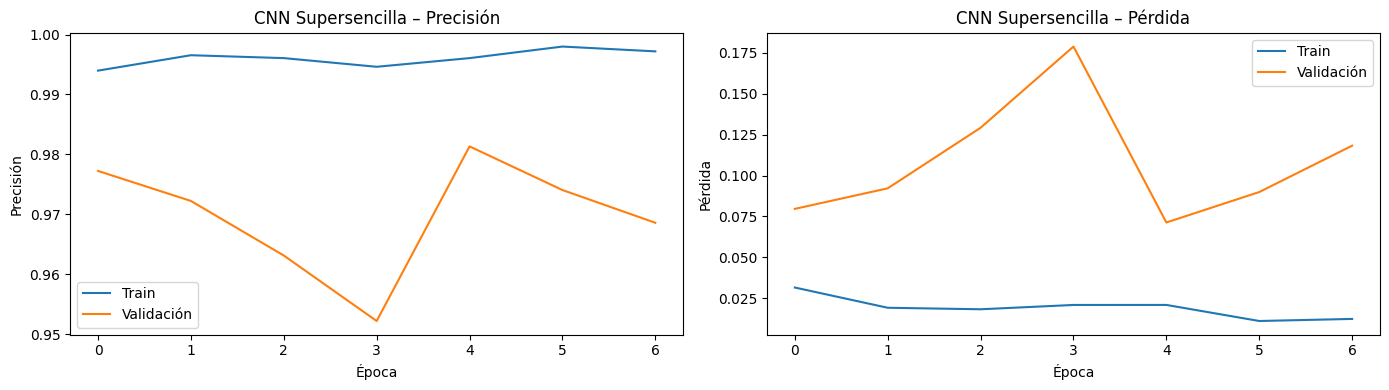

In [ ]:
cb_ss = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

history_supersimple = supersimple_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_SUPER_SENCILLA,
    batch_size=BATCH_SIZE,
    callbacks=cb_ss,
    verbose=1
)

plot_history(history_supersimple, 'CNN Supersencilla')

CNN Supersencilla – Test accuracy: 0.9143 (91.4%)


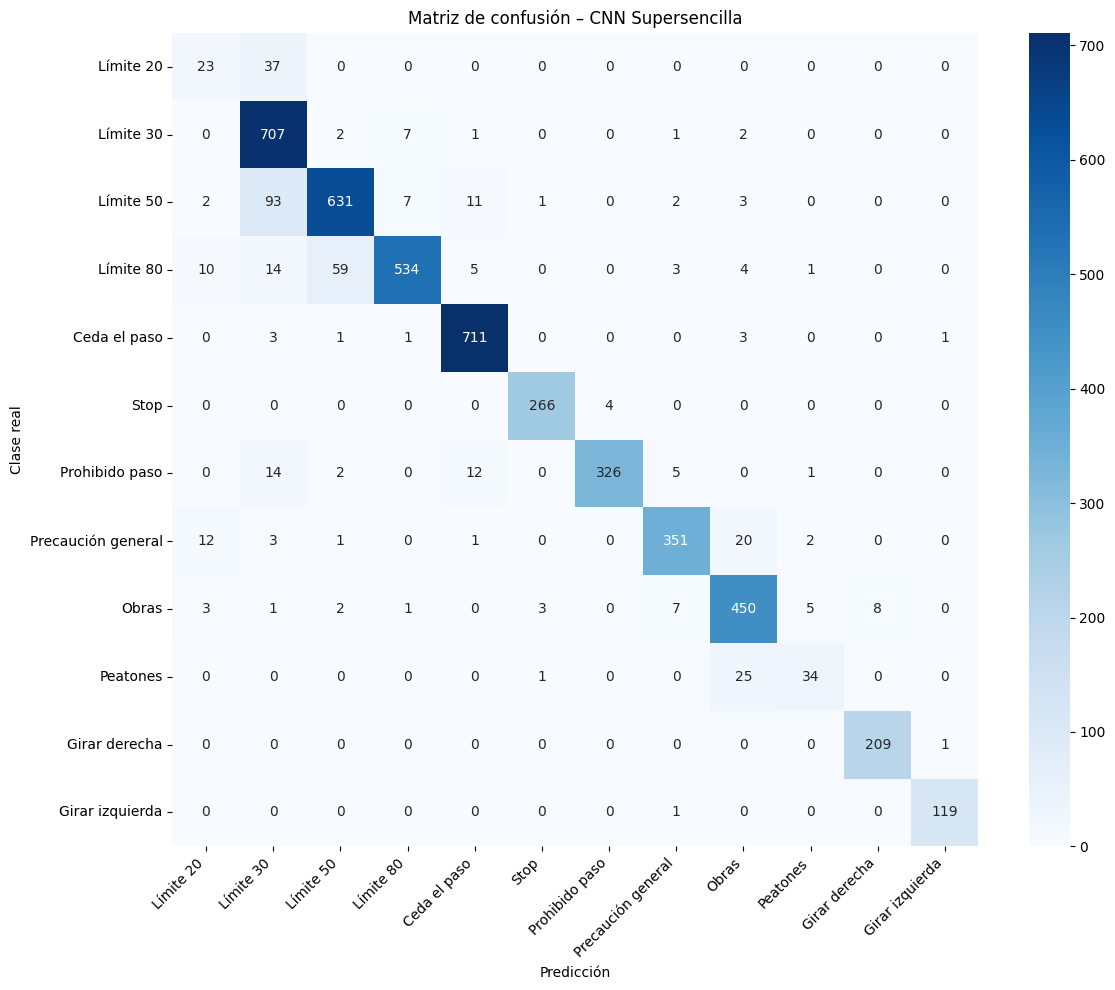

                    precision    recall  f1-score   support

         Límite 20       0.46      0.38      0.42        60
         Límite 30       0.81      0.98      0.89       720
         Límite 50       0.90      0.84      0.87       750
         Límite 80       0.97      0.85      0.91       630
      Ceda el paso       0.96      0.99      0.97       720
              Stop       0.98      0.99      0.98       270
    Prohibido paso       0.99      0.91      0.94       360
Precaución general       0.95      0.90      0.92       390
             Obras       0.89      0.94      0.91       480
          Peatones       0.79      0.57      0.66        60
     Girar derecha       0.96      1.00      0.98       210
   Girar izquierda       0.98      0.99      0.99       120

          accuracy                           0.91      4770
         macro avg       0.89      0.86      0.87      4770
      weighted avg       0.92      0.91      0.91      4770



In [ ]:
loss_ss, acc_ss = supersimple_model.evaluate(X_test, y_test, verbose=0)
print(f'CNN Supersencilla – Test accuracy: {acc_ss:.4f} ({acc_ss*100:.1f}%)')

y_pred_ss = np.argmax(supersimple_model.predict(X_test, verbose=0), axis=1)
plot_cm(y_test, y_pred_ss, 'CNN Supersencilla')

### 2.2 CNN Simple

Arquitectura básica:
```
Entrada (64×64×3)
  → Conv2D(32)  → MaxPool
  → Conv2D(64)  → MaxPool
  → Flatten → Dense(128) → Dropout(0.5)
  → Softmax (12 clases)
```

La capa última de convolución importante para Grad-CAM es **`conv2_1`**.

In [ ]:
def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1_1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2_1'),
        layers.MaxPooling2D((2,2), name='pool2'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='predictions'),
    ], name='CNN_Simple')
    m.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

simple_model = build_simple_cnn()
simple_model.summary()

Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,118,220 (8.08 MB)

 Trainable params: 2,118,220 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.5418 - loss: 1.3018 - val_accuracy: 0.8543 - val_loss: 0.4893 - learning_rate: 0.0010
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8360 - loss: 0.4647 - val_accuracy: 0.9476 - val_loss: 0.1972 - learning_rate: 0.0010
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9119 - loss: 0.2572 - val_accuracy: 0.9731 - val_loss: 0.0935 - learning_rate: 0.0010
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9361 - loss: 0.1836 - val_accuracy: 0.9804 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9490 - loss: 0.1469 - val_accuracy: 0.9800 - val_loss: 0.0592 - learning_rate: 0.0010
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9569 - loss: 0.1218 - val_accuracy: 0.9850 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9619 

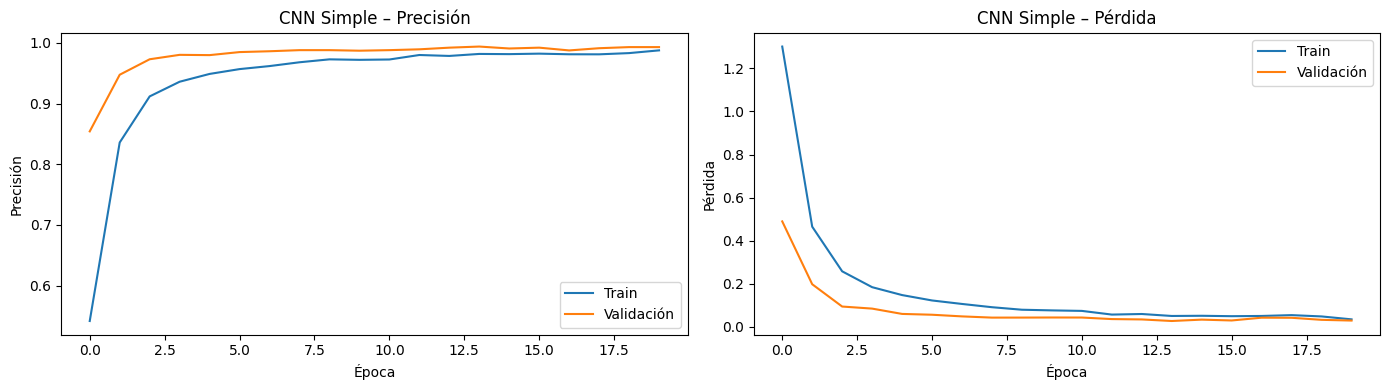

In [ ]:
cb = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]

history_simple = simple_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    verbose=1
)

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, ylabel in [
        (axes[0], 'accuracy', 'Precisión'),
        (axes[1], 'loss',     'Pérdida')
    ]:
        ax.plot(history.history[metric],          label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Validación')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} – {ylabel}')
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_simple, 'CNN Simple')

CNN Simple – Test accuracy: 0.9642 (96.4%)


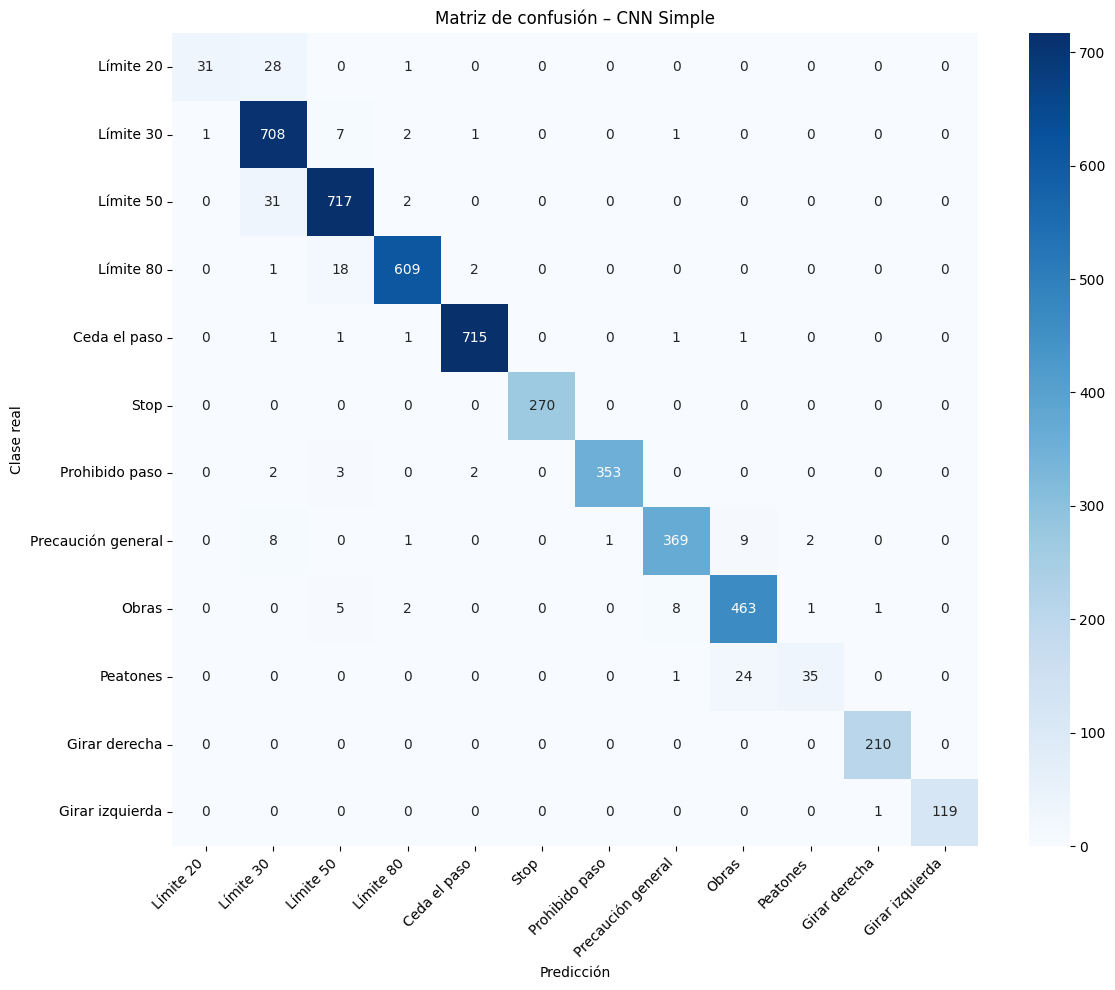

                    precision    recall  f1-score   support

         Límite 20       0.97      0.52      0.67        60
         Límite 30       0.91      0.98      0.94       720
         Límite 50       0.95      0.96      0.96       750
         Límite 80       0.99      0.97      0.98       630
      Ceda el paso       0.99      0.99      0.99       720
              Stop       1.00      1.00      1.00       270
    Prohibido paso       1.00      0.98      0.99       360
Precaución general       0.97      0.95      0.96       390
             Obras       0.93      0.96      0.95       480
          Peatones       0.92      0.58      0.71        60
     Girar derecha       0.99      1.00      1.00       210
   Girar izquierda       1.00      0.99      1.00       120

          accuracy                           0.96      4770
         macro avg       0.97      0.91      0.93      4770
      weighted avg       0.96      0.96      0.96      4770



In [ ]:
loss_s, acc_s = simple_model.evaluate(X_test, y_test, verbose=0)
print(f'CNN Simple – Test accuracy: {acc_s:.4f} ({acc_s*100:.1f}%)')

y_pred_s = np.argmax(simple_model.predict(X_test, verbose=0), axis=1)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Clase real')
    ax.set_title(f'Matriz de confusión – {title}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

plot_cm(y_test, y_pred_s, 'CNN Simple')

### 2.3 CNN Compleja

Arquitectura con tres bloques convolucionales y técnicas  de regularización:

```
Entrada (64×64×3)
  → Data Augmentation (rotación, zoom, traslación, contraste)
  → Bloque 1: Conv2D(32) × 2 + BatchNorm + MaxPool + Dropout(0.20)
  → Bloque 2: Conv2D(64) × 2 + BatchNorm + MaxPool + Dropout(0.30)
  → Bloque 3: Conv2D(128) × 2 + BatchNorm + MaxPool + Dropout(0.40)
  → GlobalAveragePooling2D
  → Dense(256) + Dropout(0.50)
  → Softmax (12 clases)
```



In [ ]:
def build_complex_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    data_aug = tf.keras.Sequential([
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.10),
    ], name='data_augmentation')

    inputs = layers.Input(shape=input_shape)
    x = data_aug(inputs)

    # Bloque 1 – bordes y colores simples
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.20)(x)

    # Bloque 2 – formas de señales
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.30)(x)

    # Bloque 3 – símbolos, números y detalles finos
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    x = layers.Dropout(0.40)(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='CNN_Compleja')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

complex_model = build_complex_cnn()
complex_model.summary()

Model: "CNN_Compleja"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,908 (1.24 MB)

 Trainable params: 324,012 (1.24 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 158s 772ms/step - accuracy: 0.4384 - loss: 1.5803 - val_accuracy: 0.1430 - val_loss: 3.6752 - learning_rate: 0.0010
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 190s 978ms/step - accuracy: 0.7532 - loss: 0.6598 - val_accuracy: 0.4135 - val_loss: 1.9554 - learning_rate: 0.0010
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 179s 919ms/step - accuracy: 0.9355 - loss: 0.1979 - val_accuracy: 0.8493 - val_loss: 0.4042 - learning_rate: 0.0010
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 170s 871ms/step - accuracy: 0.9760 - loss: 0.0857 - val_accuracy: 0.9886 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 116s 594ms/step - accuracy: 0.9855 - loss: 0.0525 - val_accuracy: 0.9964 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 127s 652ms/step - accuracy: 0.9912 - loss: 0.0317 - val_accuracy: 0.9117 - val_loss: 0.2752 - learning_rate: 0.0010
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 124s 635ms/step - accura

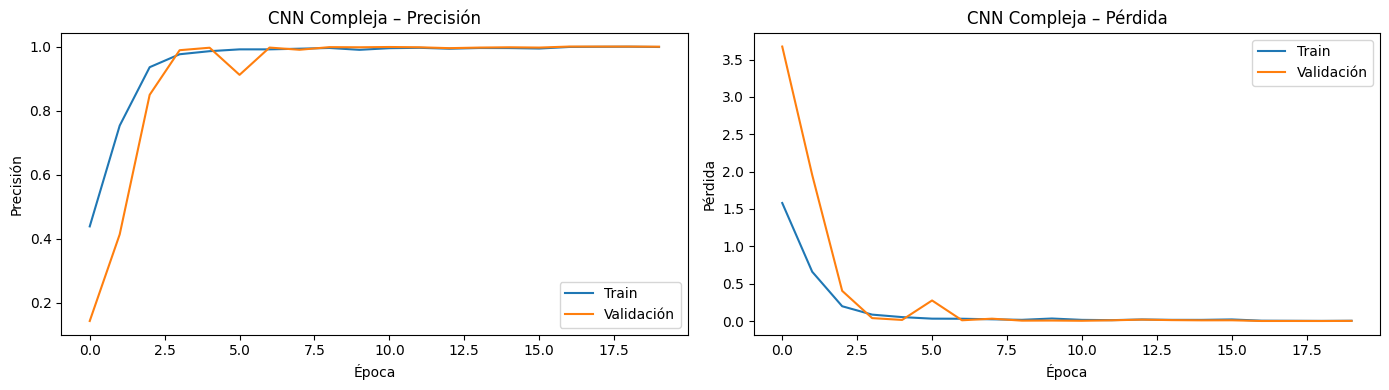

In [ ]:
cb_c = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]

history_complex = complex_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_c,
    verbose=1
)

plot_history(history_complex, 'CNN Compleja')

CNN Compleja – Test accuracy: 0.9901 (99.0%)


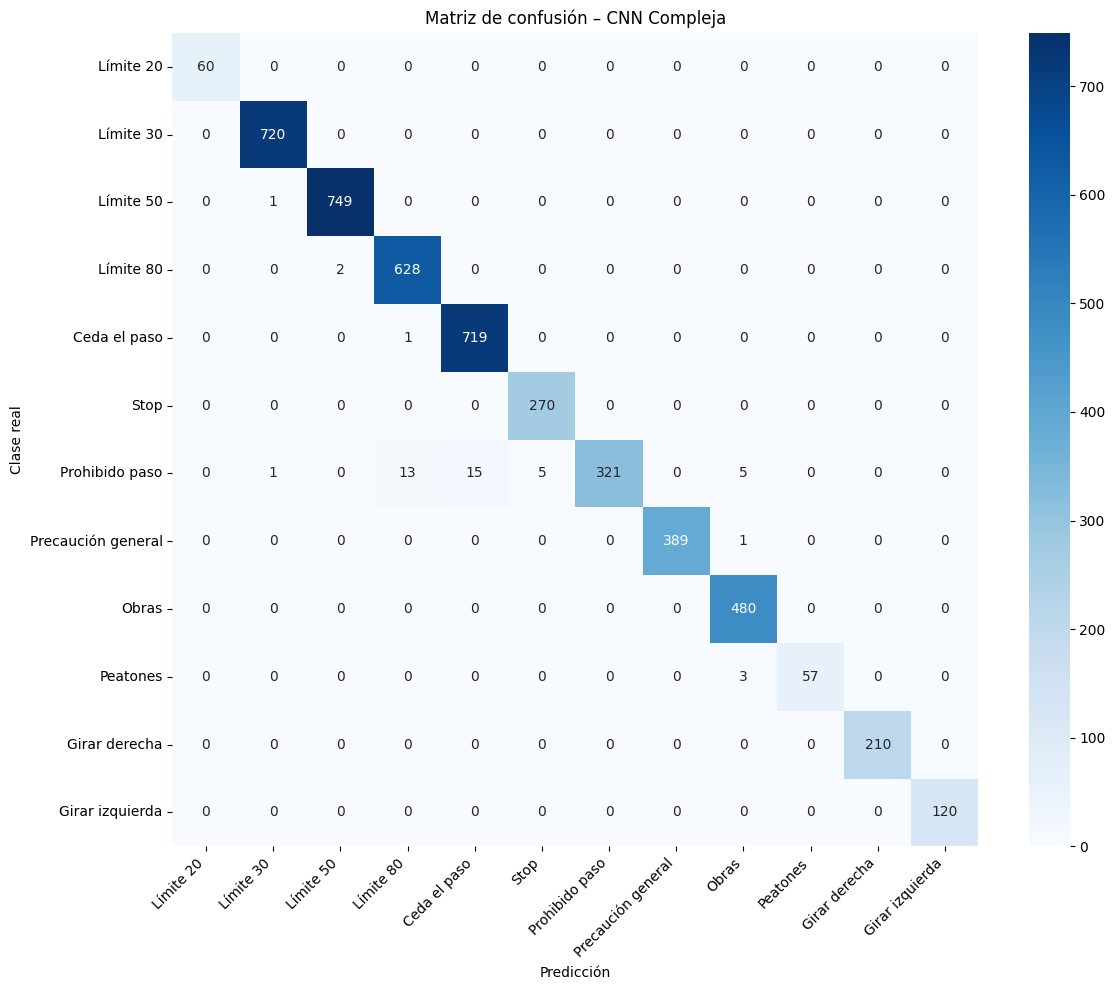

                    precision    recall  f1-score   support

         Límite 20       1.00      1.00      1.00        60
         Límite 30       1.00      1.00      1.00       720
         Límite 50       1.00      1.00      1.00       750
         Límite 80       0.98      1.00      0.99       630
      Ceda el paso       0.98      1.00      0.99       720
              Stop       0.98      1.00      0.99       270
    Prohibido paso       1.00      0.89      0.94       360
Precaución general       1.00      1.00      1.00       390
             Obras       0.98      1.00      0.99       480
          Peatones       1.00      0.95      0.97        60
     Girar derecha       1.00      1.00      1.00       210
   Girar izquierda       1.00      1.00      1.00       120

          accuracy                           0.99      4770
         macro avg       0.99      0.99      0.99      4770
      weighted avg       0.99      0.99      0.99      4770



In [ ]:
loss_c, acc_c = complex_model.evaluate(X_test, y_test, verbose=0)
print(f'CNN Compleja – Test accuracy: {acc_c:.4f} ({acc_c*100:.1f}%)')

y_pred_c = np.argmax(complex_model.predict(X_test, verbose=0), axis=1)
plot_cm(y_test, y_pred_c, 'CNN Compleja')

Modelo                    Test Accuracy
--------------------------------------------------
CNN Supersencilla                91.4%
CNN Simple                       96.4%
CNN Compleja                     99.0%


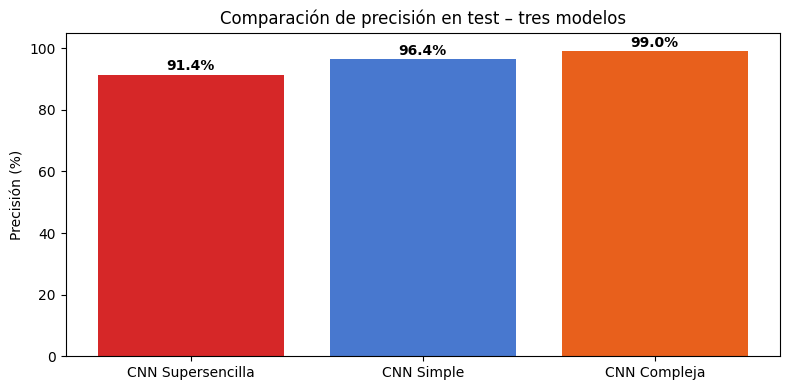

In [ ]:
# Comparación final de los tres modelos
print('=' * 50)
print(f"{'Modelo':<25} {'Test Accuracy':>12}")
print('-' * 50)
print(f"{'CNN Supersencilla':<25} {acc_ss*100:>11.1f}%")
print(f"{'CNN Simple':<25} {acc_s*100:>11.1f}%")
print(f"{'CNN Compleja':<25} {acc_c*100:>11.1f}%")
print('=' * 50)

fig, ax = plt.subplots(figsize=(8, 4))
modelos = ['CNN Supersencilla', 'CNN Simple', 'CNN Compleja']
accs    = [acc_ss*100, acc_s*100, acc_c*100]
colors  = ['#d62728', '#4878cf', '#e8601c']
bars = ax.bar(modelos, accs, color=colors)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Precisión (%)')
ax.set_title('Comparación de precisión en test – tres modelos')
plt.tight_layout()
plt.show()

Como hemos visto en las celdas anteriores, los tres modelos obtienen resultados bastante buenos, aunque no todos aprenden con el mismo nivel de detalle. La CNN Compleja es la que mejor funciona, con un accuracy del 99,0 %, seguida de la CNN Simple con un 96,4 % y la CNN Supersencilla con un 91,4 %.

A primera vista, los tres modelos parecen fiables, porque sus accuracies son altos y sus matrices de confusión tienen muchos valores en la diagonal. Sin embargo, al mirar los errores con más detalle, se ve que tanto la CNN sencilla, como la Supersencilla fallan más en las clases que se parecen entre sí, sobre todo en las señales de límite de velocidad. Estas señales tienen la misma forma, el mismo borde rojo y el mismo fondo blanco, y solo cambia el número del centro.

Esto indica que los modelos más básicos aprenden bien las diferencias grandes, como la forma o el color de una señal, pero tienen más dificultades para captar detalles pequeños, como distinguir un 30 de un 50. En cambio, el modelo Complejo, al tener más capas convolucionales, consigue extraer mejor esos detalles y reduce mucho este tipo de error.

Por eso, aunque las CNN sencillas tienen un accuracy alto, en la matriz de confusión vemos que no funciona igual en todas las clases. El resultado general parece bueno porque aciertan muchas señales fáciles, que se reconocen por la forma o el color. Pero cuando las señales se parecen mucho entre sí los modelos se equivocan más. Esto nos indica que las redes igual no están detectando bien la parte más importante de la imagen. Y que se puede estar fijándo en rasgos más generales.

Por ello, el análisis explicable es importante. No sirve con mirar solo el accuracy, porque puede ocultar fallos en clases concretas. También hay que ver en qué señales se equivoca el modelo y si está mirando las zonas correctas de la imagen.







---
## 3. Métodos XAI

Usamos cuatro métodos de explicabilidad para analizar en qué partes de la imagen se fija cada modelo al hacer una predicción. Aunque todos tienen el mismo objetivo, explicar la decisión de la red, cada uno lo hace de una forma distinta y aporta información diferente.

- Grad-CAM

  Utiliza los gradientes de la última capa convolucional para generar un mapa de calor sobre la imagen. Las zonas más activadas indican qué regiones han sido más importantes para la predicción. Es útil para ver la atención general del modelo, aunque el mapa suele tener poca resolución y no siempre localiza detalles pequeños con precisión.

- Integrated Gradients

  Calcula la importancia de cada píxel acumulando gradientes desde una imagen base, normalmente negra, hasta la imagen original. Permite obtener explicaciones más detalladas y ver qué partes exactas de la imagen aumentan o reducen la predicción del modelo.

- Oclusión

  Consiste en tapar partes de la imagen con un parche gris y medir cuánto cambia la probabilidad de la clase correcta. Si al ocultar una región la predicción cae mucho, significa que esa zona era importante para el modelo. Es un método sencillo e interpretable porque mide directamente el efecto de eliminar información visual.

- LIME

  Divide la imagen en regiones o superpíxeles y prueba distintas combinaciones para aproximar localmente el comportamiento del modelo. Las regiones resaltadas son las que parecen más importantes para que el modelo mantenga la predicción. A diferencia de Grad-CAM o Integrated Gradients, trabaja sobre zonas completas de la imagen y no sobre píxeles individuales.




In [ ]:

# Implementación de los cuatro métodos XAI

#  Grad-CAM
def compute_gradcam(model, img, layer_name, class_idx=None):
    """Devuelve un mapa de calor (H, W) con valores en [0, 1]."""

    # Forzar que el modelo quede llamado/construido
    _ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)), training=False)

    # En Keras 3 es más seguro usar model.outputs[0] que model.output
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.outputs[0]]
    )

    x = tf.constant(img[np.newaxis], dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x, training=False)

        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))

        score = preds[:, class_idx]

    grads   = tape.gradient(score, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))

    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1).numpy()
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam = tf.image.resize(
        cam[..., np.newaxis],
        [IMG_SIZE, IMG_SIZE]
    ).numpy()[..., 0]

    return cam


#  Integrated Gradients
def compute_ig(model, img, class_idx, steps=50):
    """Devuelve (atribuciones en canal RGB, mapa agregado [0,1])."""
    baseline = np.zeros_like(img, dtype=np.float32)
    diff     = img - baseline
    alphas   = np.linspace(0.0, 1.0, steps)[:, None, None, None]
    interp   = (baseline + alphas * diff).astype(np.float32)

    x_tensor = tf.constant(interp)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        preds  = model(x_tensor, training=False)
        target = preds[:, class_idx]
    grads     = tape.gradient(target, x_tensor).numpy()
    avg_grads = grads.mean(axis=0)
    ig        = diff[0] * avg_grads
    ig_map    = np.abs(ig).mean(axis=-1)
    ig_map    = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)
    return ig, ig_map


#  Oclusión
def compute_occlusion(model, img, class_idx, patch=16, stride=8):
    """Devuelve mapa de caída de probabilidad (normalizado [0,1]) y prob base."""
    H, W     = img.shape[:2]
    base_p   = float(model.predict(img[np.newaxis], verbose=0)[0, class_idx])
    drop_map = np.zeros((H, W), dtype=np.float32)
    cnt_map  = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            occ = img.copy()
            occ[y:y+patch, x:x+patch] = 0.5
            p   = float(model.predict(occ[np.newaxis], verbose=0)[0, class_idx])
            drop_map[y:y+patch, x:x+patch] += base_p - p
            cnt_map [y:y+patch, x:x+patch] += 1.0

    cnt_map  = np.where(cnt_map == 0, 1, cnt_map)
    drop_map = drop_map / cnt_map
    drop_map = np.clip(drop_map, 0, None)
    drop_map = (drop_map - drop_map.min()) / (drop_map.max() - drop_map.min() + 1e-8)
    return drop_map, base_p


#  LIME
def compute_lime(model, img, class_idx, num_samples=2000, num_features=6):
    """Devuelve (imagen con superpíxeles, máscara binaria)."""
    explainer = lime_image.LimeImageExplainer(random_state=SEED)
    img_u8    = (img * 255).astype(np.uint8)

    def predict_fn(imgs):
        return model.predict(imgs.astype(np.float32) / 255.0, verbose=0)

    exp = explainer.explain_instance(
        img_u8, predict_fn,
        top_labels=NUM_CLASSES,
        hide_color=128,
        num_samples=num_samples,
        random_seed=SEED
    )
    temp, mask = exp.get_image_and_mask(
        class_idx, positive_only=True,
        num_features=num_features, hide_rest=False
    )
    return temp.astype(np.float32) / 255.0, mask


print('Métodos XAI definidos: Grad-CAM, Integrated Gradients, Oclusión, LIME')

Métodos XAI definidos: Grad-CAM, Integrated Gradients, Oclusión, LIME


In [ ]:
# Funciones de visualización

def visualize_xai_row(model, img, true_idx, layer_name, title=''):
    """Muestra una fila con 5 paneles: original + Grad-CAM + IG + Oclusión + LIME."""
    pred     = model.predict(img[np.newaxis], verbose=0)[0]
    pred_idx = int(np.argmax(pred))
    pred_p   = pred[pred_idx]
    correct  = '✓' if pred_idx == true_idx else '✗'

    cam              = compute_gradcam(model, img, layer_name, true_idx)
    _, ig_map        = compute_ig(model, img, true_idx)
    occ_map, _       = compute_occlusion(model, img, true_idx)
    lime_img, l_mask = compute_lime(model, img, true_idx)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(img)
    axes[0].set_title(
        f'Original\nReal: {CLASS_NAMES[true_idx]}\n'
        f'Pred: {CLASS_NAMES[pred_idx]} {correct}\n({pred_p:.1%})'
    )

    axes[1].imshow(img)
    axes[1].imshow(cam, alpha=0.55, cmap='jet')
    axes[1].set_title('Grad-CAM\n(mapa grueso)')

    axes[2].imshow(img)
    axes[2].imshow(ig_map, alpha=0.55, cmap='hot')
    axes[2].set_title('Integrated Gradients\n(detalle por píxel)')

    axes[3].imshow(img)
    axes[3].imshow(occ_map, alpha=0.55, cmap='RdYlGn_r')
    axes[3].set_title('Oclusión\n(caída de prob.)')

    axes[4].imshow(mark_boundaries(lime_img, l_mask))
    axes[4].set_title('LIME\n(superpíxeles)')

    for ax in axes:
        ax.axis('off')

    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_all_models(img, true_idx, title=''):
    """Aplica los cuatro métodos XAI a los tres modelos y muestra una fila por modelo."""
    print('\n>>> CNN Supersencilla')
    visualize_xai_row(supersimple_model, img, true_idx, layer_name='ss_conv1',
                      title=f'{title} – CNN Supersencilla')
    print('\n>>> CNN Simple')
    visualize_xai_row(simple_model, img, true_idx, layer_name='conv2_1',
                      title=f'{title} – CNN Simple')
    print('\n>>> CNN Compleja')
    visualize_xai_row(complex_model, img, true_idx, layer_name='conv3_2',
                      title=f'{title} – CNN Compleja')


def get_sample(class_idx, split='test', n=0):
    """Devuelve la n-ésima imagen de una clase del split pedido."""
    X = X_test if split == 'test' else X_train
    y = y_test if split == 'test' else y_train
    idxs = np.where(y == class_idx)[0]
    return X[idxs[n]]


Funciones de visualización listas.


---
## 4. Análisis de casos

Para cada caso elegimos imágenes del conjunto de test y aplicamos los cuatro métodos XAI a los tres modelos: CNN Supersencilla, CNN Simple y CNN Compleja.

Buscamos contestar siempre a las preguntas: ¿mira el modelo la parte correcta de la señal? y ¿cómo cambia la respuesta según la capacidad del modelo?


### **Caso 1 – Límite de velocidad 30**

**Pregunta: ¿El modelo mira el número 30 dentro del círculo, o solo detecta el borde rojo?**

Si mira solo el borde rojo, no podría distinguir entre un límite 20, un límite 50 o un límite 80, porque todos tienen el mismo borde.    El número es la única diferencia real entre estas señales.

Esperamos que las explicaciones resalten la zona central de la imagen, donde están los dígitos.

CASO 1: Límite 30

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:26<00:00, 75.11it/s] 


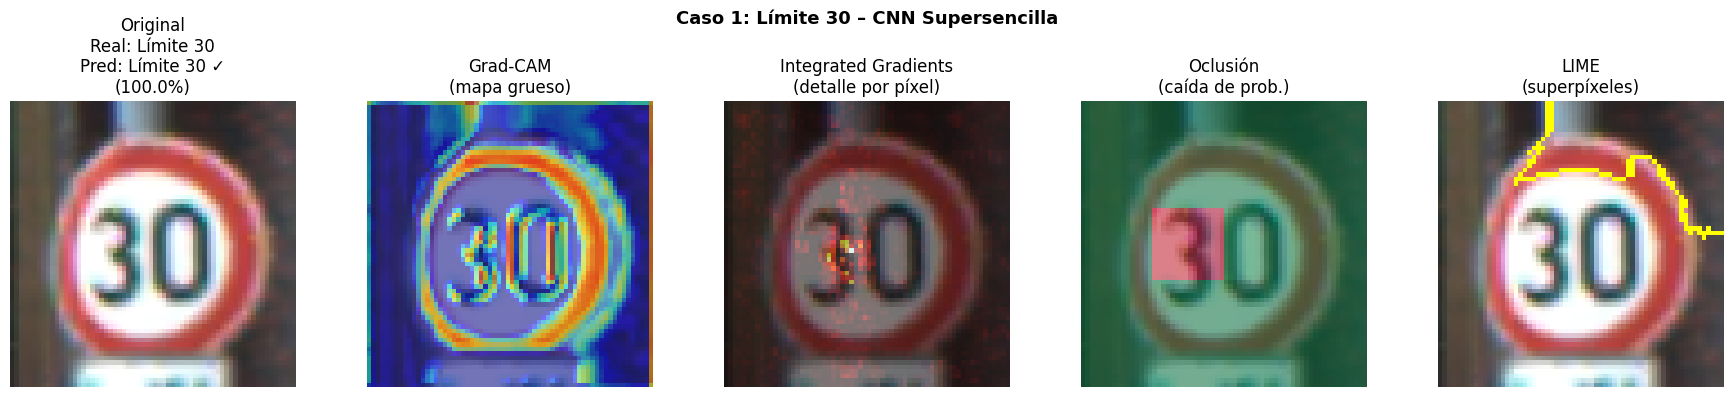


>>> CNN Simple


100%|██████████| 2000/2000 [00:25<00:00, 78.91it/s]


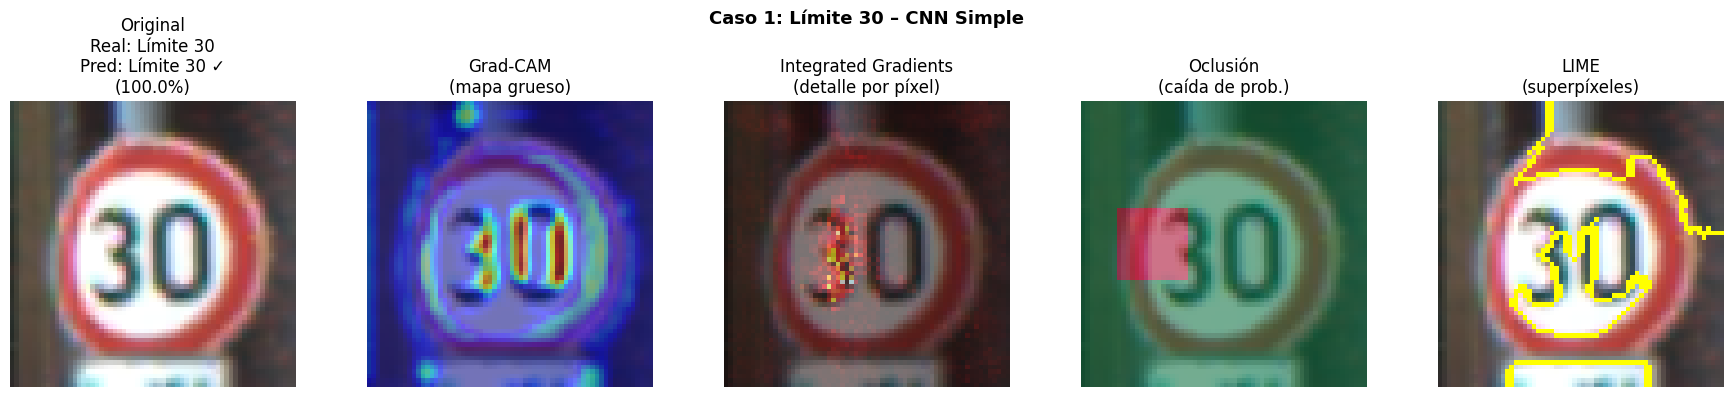


>>> CNN Compleja


100%|██████████| 2000/2000 [00:28<00:00, 71.04it/s]


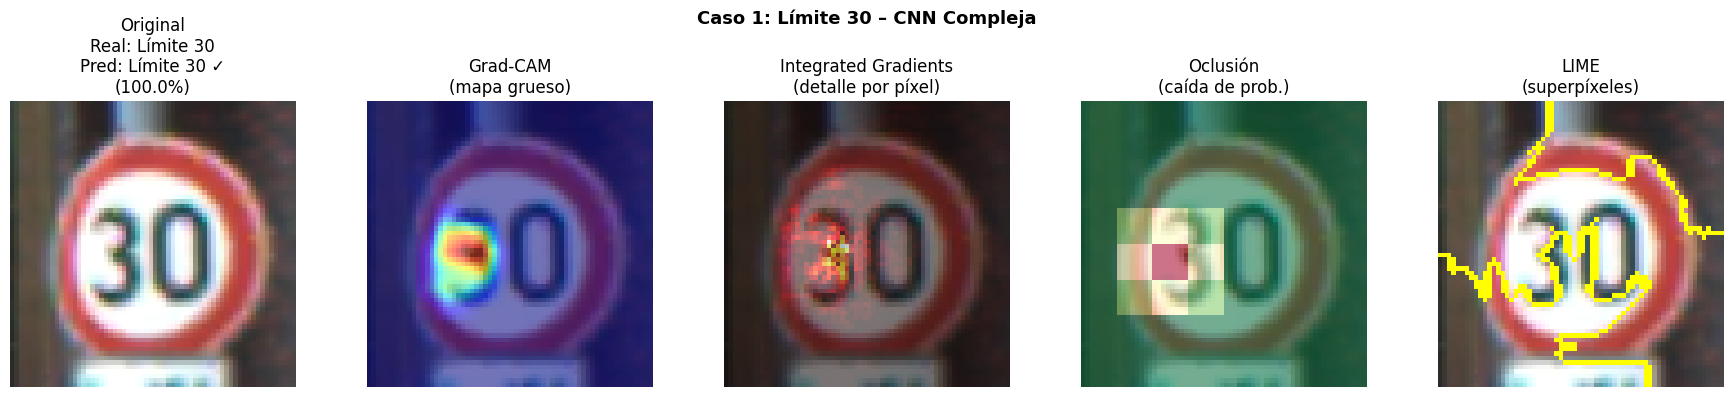

In [ ]:
# Clase 1 en nuestro índice = Límite 30 (ID original = 1)
idx_30 = CLASS_NAMES.index('Límite 30')
img_30 = get_sample(idx_30, split='test', n=0)

print('CASO 1: Límite 30')
compare_all_models(img_30, idx_30, title='Caso 1: Límite 30')

#### **Conclusiones – Caso 1: Límite 30**

En este caso, los tres modelos clasifican correctamente la imagen como Límite 30 con una confianza muy alta. Sin embargo, las explicaciones muestran que no todos llegan a esa predicción usando la misma información de la imagen.

La CNN Supersencilla parece basarse principalmente en rasgos muy generales de la señal, como el borde rojo circular y la forma global. Esto se ve sobre todo en Grad-CAM, donde la activación aparece bastante extendida por el contorno de la señal. En Integrated Gradients aparece algo de importancia sobre el número, pero de forma poco clara, mientras que LIME se centra principalmente en el borde rojo y en zonas del contorno. Por tanto, el modelo no parece estar identificando del todo el 30, sino que se apoya mucho en la asociación entre círculo rojo y señal de límite de velocidad, utilizando un atajo visual. El problema es que este razonamiento puede servir para reconocer el tipo general de señal, pero no es suficiente para diferenciar de forma fiable entre límites como 20, 30, 50 u 80, que comparten forma y color.

La CNN Simple muestra una explicación más equilibrada que la CNN Supersencilla. En Grad-CAM, la activación sigue incluyendo parte del borde rojo, pero ya empieza a concentrarse más hacia el interior de la señal. En Integrated Gradients aparece más información relacionada con los dígitos, aunque todavía no de forma completamente limpia. La oclusión también sugiere que ocultar zonas internas del número afecta a la confianza del modelo, por lo que la red ya no parece depender únicamente del contorno. Aun así, el borde rojo todavía mantiene cierto peso en la decisión, por lo que este modelo estaría en un punto intermedio: usa parte de la información correcta, pero todavía conserva apoyo en rasgos generales de la señal.

La CNN Compleja muestra una explicación más centrada que las anteriores. En Grad-CAM, la activación principal se concentra sobre la parte izquierda del número, especialmente cerca del dígito 3, mientras que en la CNN Supersencilla el mapa estaba mucho más extendido por el borde y la forma general. En Integrated Gradients también aparece importancia sobre los trazos del 3, aunque todavía aparecen pequeñas activaciones en la zona del borde. La oclusión refuerza esta idea, ya que la zona que más afecta a la predicción está situada sobre el número. Sin embargo, LIME todavía marca algunas partes del borde rojo, sobre todo en la zona superior y derecha, por lo que el modelo no ignora completamente la forma de la señal. En conjunto, esta CNN parece usar más información semántica que las otras redes, aunque todavía combina el número con algunos rasgos generales del contorno.

En conjunto, los modelos más simples parecen fijarse más en el borde rojo, mientras que los modelos más complejos prestan más atención al número. La CNN Supersencilla usa sobre todo la forma general de la señal, la CNN Simple combina borde y número, y la CNN Compleja se centra más en los dígitos, aunque todavía tiene en cuenta algo del borde. Por eso, aunque los tres modelos aciertan, la CNN Compleja parece dar una explicación más adecuada para reconocer un Límite 30.

### **Caso 2 – Límite 50 vs Límite 30**

**Pregunta: Estas dos señales son casi iguales y como hemos visto en la matriz de confusión, las que más cuesta identificar. El círculo rojo es igual, el fondo blanco es igual. La única diferencia es el número: 50 o 30. ¿Qué pasa si tapamos el número? ¿Y si tapamos el borde?**

Hacemos una prueba con oclusión manual:
1. Tapamos la zona central con un parche gris.
2. Tapamos el borde exterior de la señal.
3. Medimos cuánto cae la probabilidad de la clase correcta.

Esperamos que al tapar el número caerá mucho la probabilidad, el modelo usará la información correcta. Si al tapar el borde cae también mucho, el modelo usa un atajo visual.

CASO 2: Límite 50 vs Límite 30

-- CNN Supersencilla --


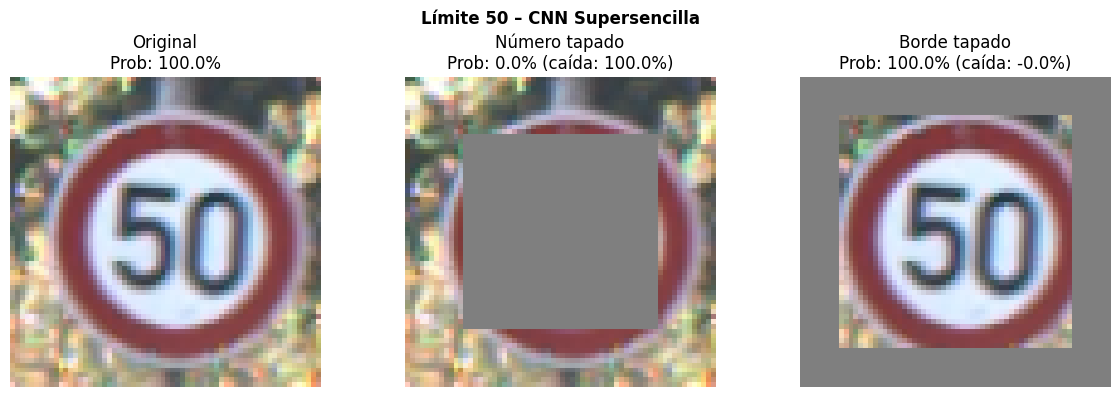

Límite 50 – CNN Supersencilla: orig=100.0% | num_tapado=0.0% (-100.0%) | borde_tapado=100.0% (--0.0%)


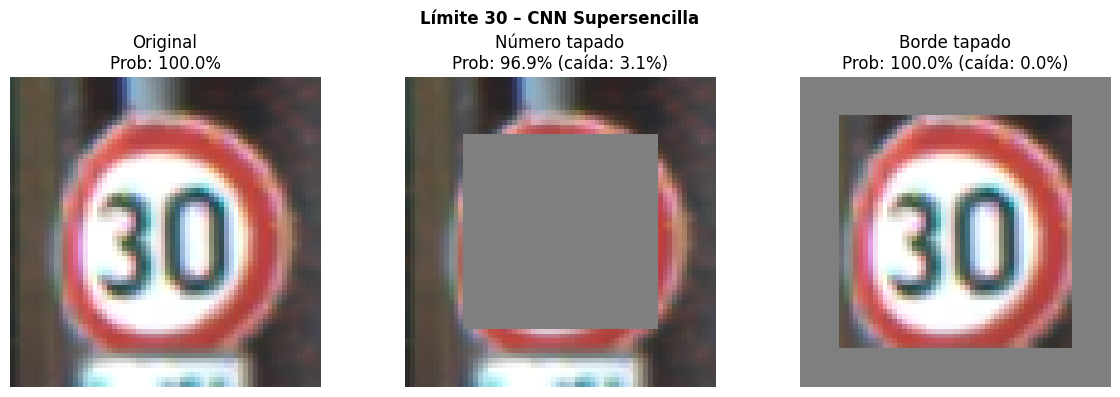

Límite 30 – CNN Supersencilla: orig=100.0% | num_tapado=96.9% (-3.1%) | borde_tapado=100.0% (-0.0%)

-- CNN Simple --


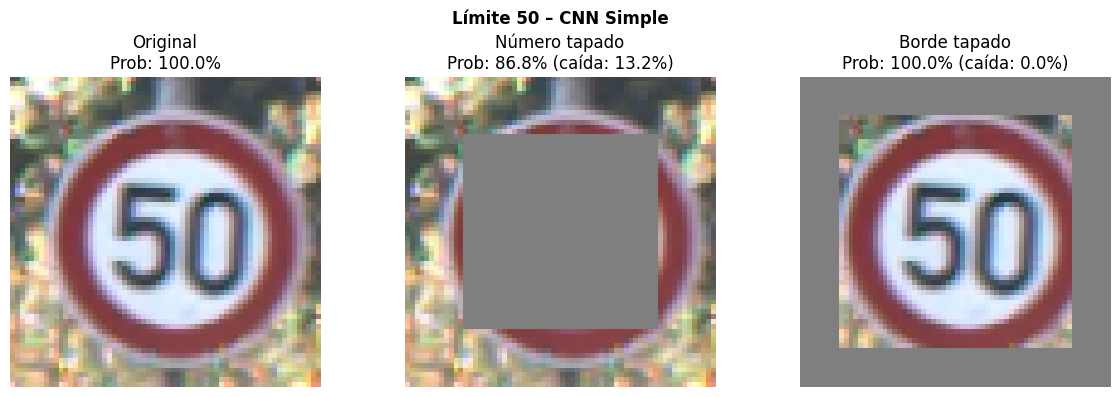

Límite 50 – CNN Simple: orig=100.0% | num_tapado=86.8% (-13.2%) | borde_tapado=100.0% (-0.0%)


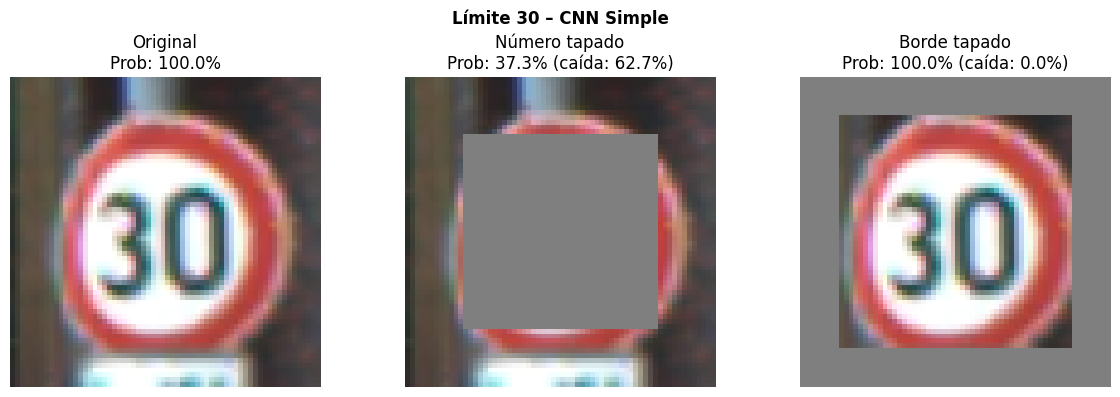

Límite 30 – CNN Simple: orig=100.0% | num_tapado=37.3% (-62.7%) | borde_tapado=100.0% (-0.0%)

-- CNN Compleja --


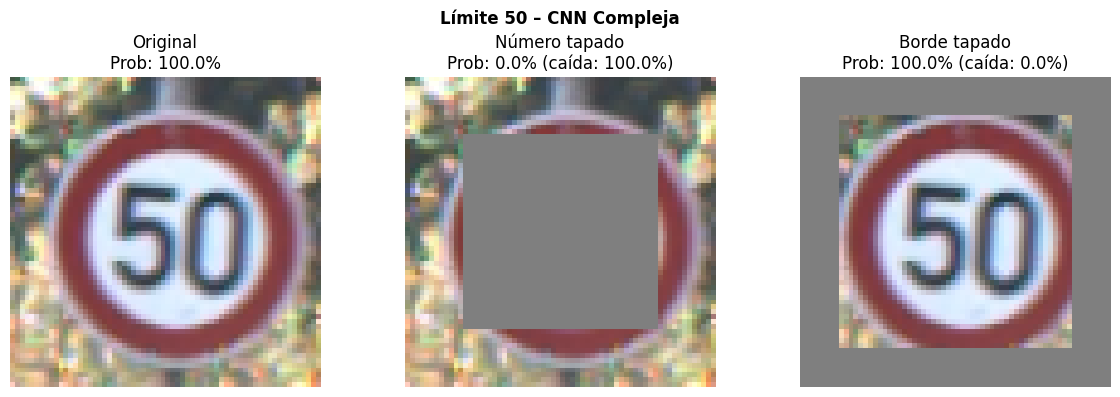

Límite 50 – CNN Compleja: orig=100.0% | num_tapado=0.0% (-100.0%) | borde_tapado=100.0% (-0.0%)


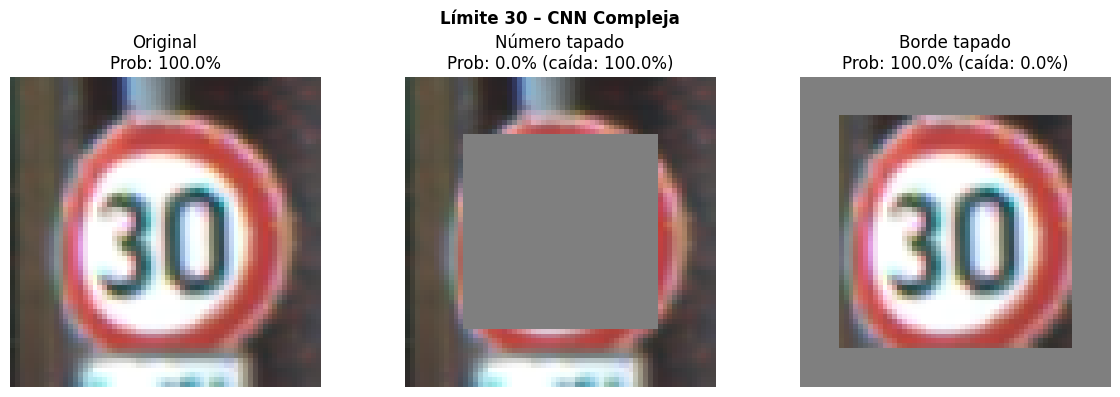

Límite 30 – CNN Compleja: orig=100.0% | num_tapado=0.0% (-100.0%) | borde_tapado=100.0% (-0.0%)


In [ ]:
idx_50 = CLASS_NAMES.index('Límite 50')
idx_30 = CLASS_NAMES.index('Límite 30')

img_50 = get_sample(idx_50, split='test', n=0)
img_30 = get_sample(idx_30, split='test', n=0)


def occlude_region(img, region='number', fill=0.5):
    """Tapa el número (centro) o el borde exterior de la señal."""
    occ = img.copy()
    H, W = img.shape[:2]

    if region == 'number':
        m = H // 5
        occ[m: H-m, m: W-m] = fill
    else:
        b = max(H // 8, 4)
        occ[:b, :]  = fill
        occ[-b:, :] = fill
        occ[:, :b]  = fill
        occ[:, -b:] = fill

    return occ


def occlusion_experiment(model, img, true_idx, label):
    orig_p   = float(model.predict(img[np.newaxis], verbose=0)[0, true_idx])
    num_occ  = occlude_region(img, 'number')
    bord_occ = occlude_region(img, 'border')

    p_num    = float(model.predict(num_occ[np.newaxis],  verbose=0)[0, true_idx])
    p_bord   = float(model.predict(bord_occ[np.newaxis], verbose=0)[0, true_idx])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Original\nProb: {orig_p:.1%}')

    axes[1].imshow(num_occ)
    axes[1].set_title(
        f'Número tapado\nProb: {p_num:.1%} '
        f'(caída: {orig_p-p_num:.1%})'
    )

    axes[2].imshow(bord_occ)
    axes[2].set_title(
        f'Borde tapado\nProb: {p_bord:.1%} '
        f'(caída: {orig_p-p_bord:.1%})'
    )

    for ax in axes:
        ax.axis('off')

    fig.suptitle(f'{label}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return orig_p, p_num, p_bord


print('CASO 2: Límite 50 vs Límite 30')

print('\n-- CNN Supersencilla --')
for img_x, idx_x, name in [
    (img_50, idx_50, 'Límite 50 – CNN Supersencilla'),
    (img_30, idx_30, 'Límite 30 – CNN Supersencilla')
]:
    o, n, b = occlusion_experiment(supersimple_model, img_x, idx_x, name)
    print(
        f'{name}: orig={o:.1%} | '
        f'num_tapado={n:.1%} (-{o-n:.1%}) | '
        f'borde_tapado={b:.1%} (-{o-b:.1%})'
    )


print('\n-- CNN Simple --')
for img_x, idx_x, name in [
    (img_50, idx_50, 'Límite 50 – CNN Simple'),
    (img_30, idx_30, 'Límite 30 – CNN Simple')
]:
    o, n, b = occlusion_experiment(simple_model, img_x, idx_x, name)
    print(
        f'{name}: orig={o:.1%} | '
        f'num_tapado={n:.1%} (-{o-n:.1%}) | '
        f'borde_tapado={b:.1%} (-{o-b:.1%})'
    )


print('\n-- CNN Compleja --')
for img_x, idx_x, name in [
    (img_50, idx_50, 'Límite 50 – CNN Compleja'),
    (img_30, idx_30, 'Límite 30 – CNN Compleja')
]:
    o, n, b = occlusion_experiment(complex_model, img_x, idx_x, name)
    print(
        f'{name}: orig={o:.1%} | '
        f'num_tapado={n:.1%} (-{o-n:.1%}) | '
        f'borde_tapado={b:.1%} (-{o-b:.1%})'
    )




-- Explicaciones XAI completas (Límite 50) --

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:18<00:00, 106.78it/s]


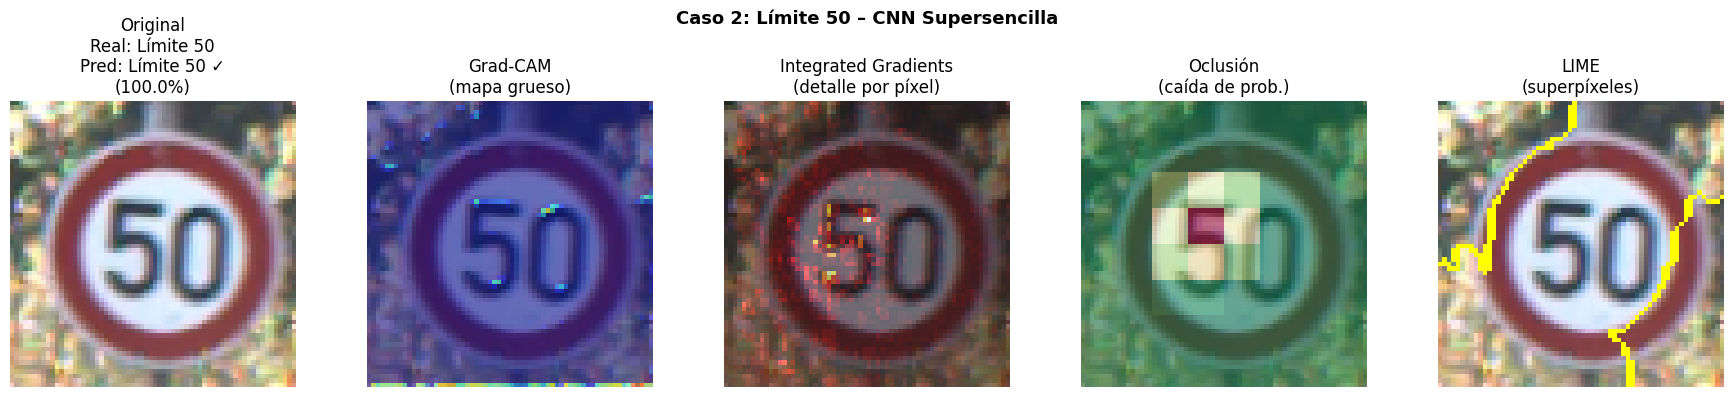


>>> CNN Simple


100%|██████████| 2000/2000 [00:19<00:00, 101.82it/s]


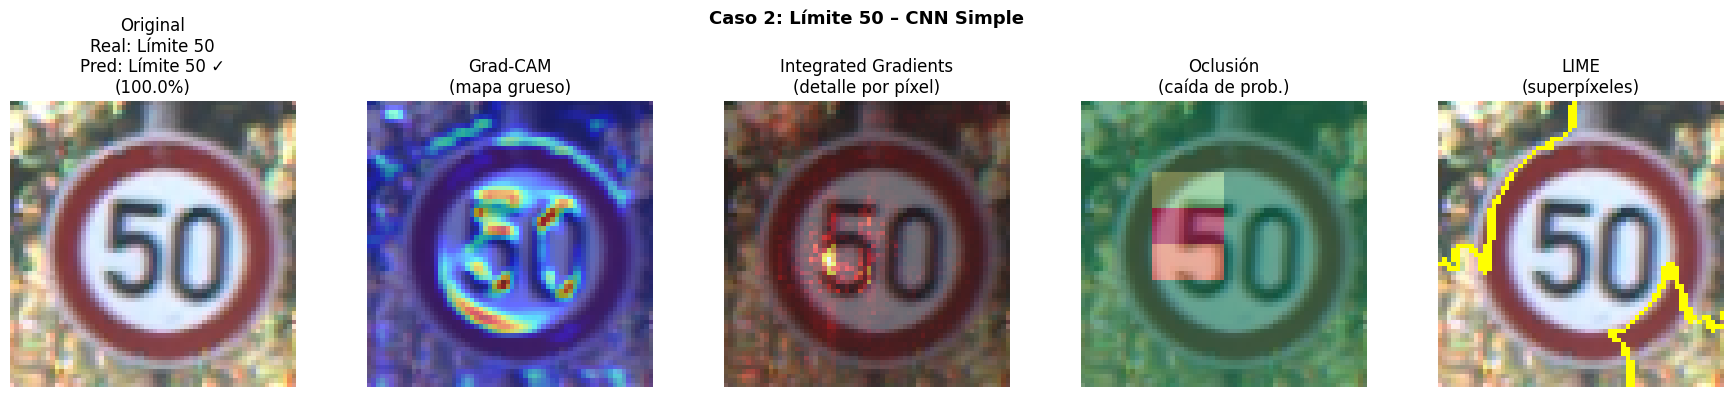


>>> CNN Compleja


100%|██████████| 2000/2000 [00:22<00:00, 89.94it/s] 


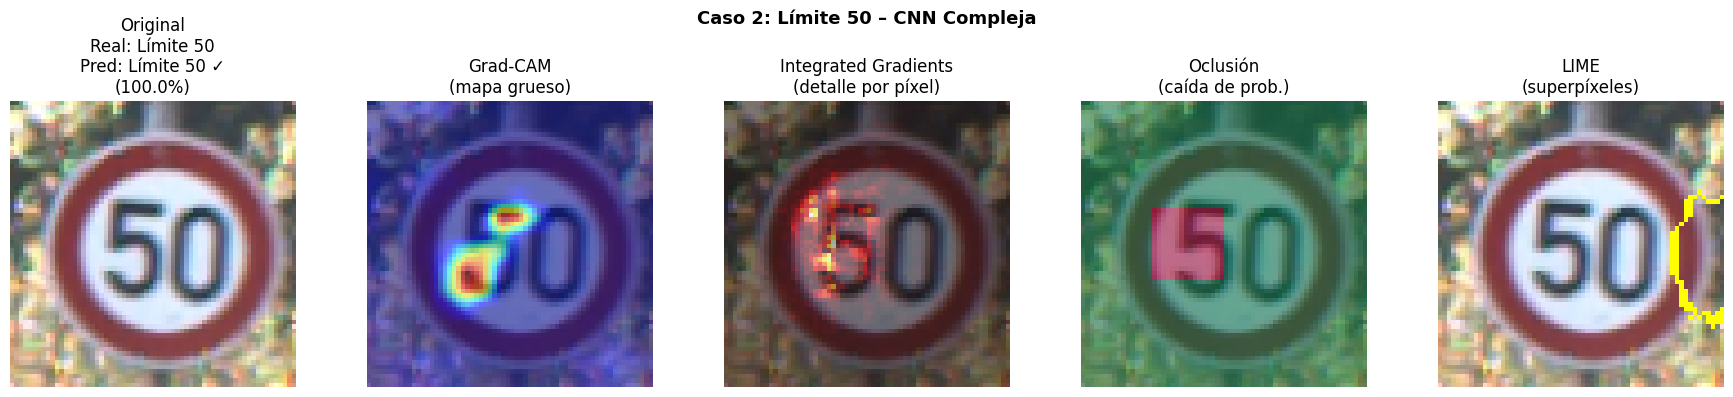


-- Explicaciones XAI completas (Límite 30) --

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:20<00:00, 97.64it/s] 


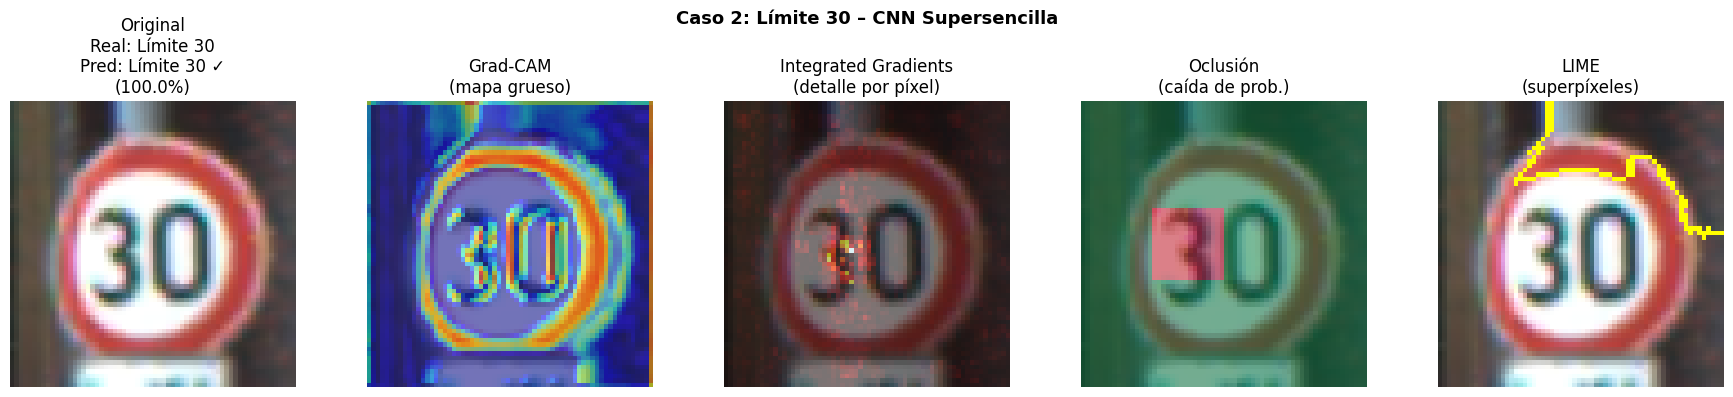


>>> CNN Simple


100%|██████████| 2000/2000 [00:21<00:00, 91.59it/s] 


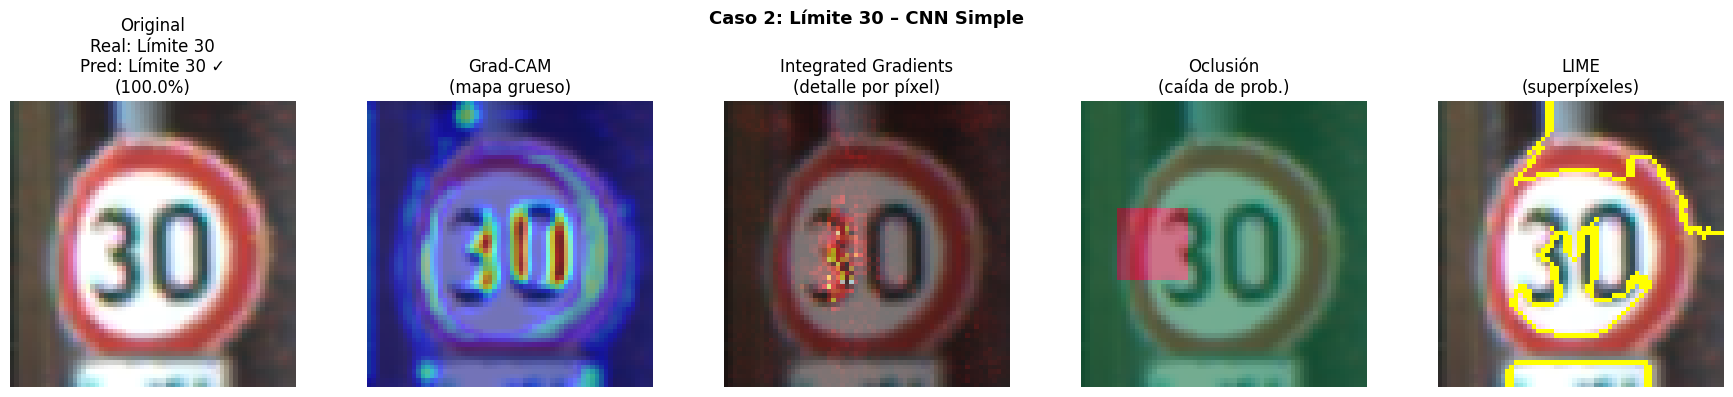


>>> CNN Compleja


100%|██████████| 2000/2000 [00:23<00:00, 85.20it/s]


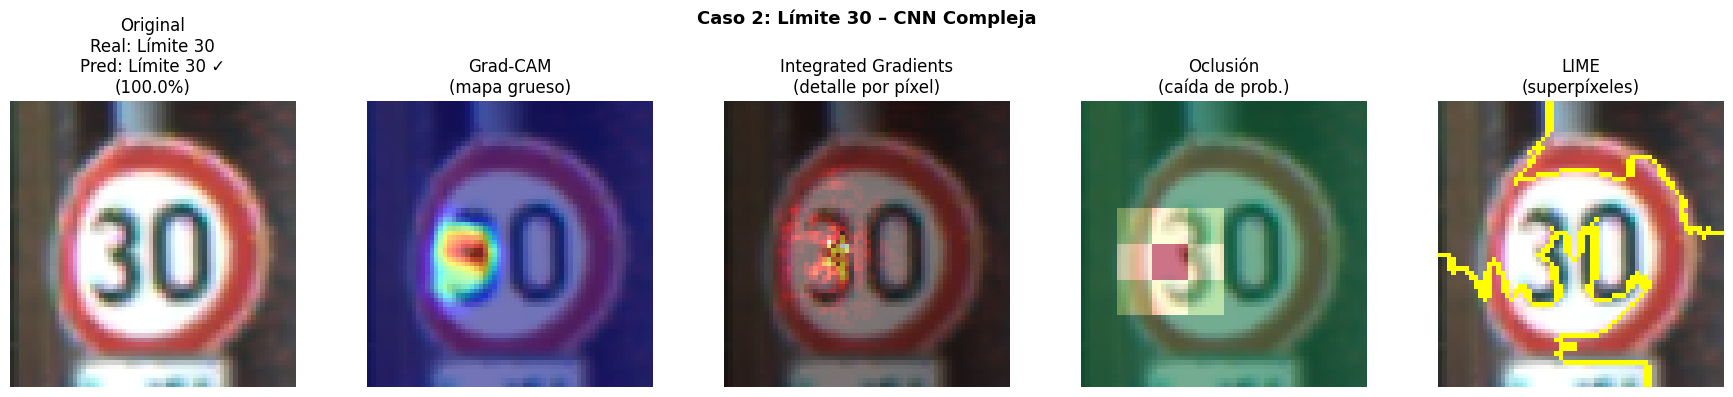

In [ ]:

print('\n-- Explicaciones XAI completas (Límite 50) --')
compare_all_models(img_50, idx_50, title='Caso 2: Límite 50')

print('\n-- Explicaciones XAI completas (Límite 30) --')
compare_all_models(img_30, idx_30, title='Caso 2: Límite 30')

#### **Conclusiones – Caso 2: Límite 50 vs Límite 30**

Las señales de Límite 50 y Límite 30 son muy parecidas. La única diferencia es el número del centro. Por eso, este caso nos sirve para comprobar si los modelos están mirando realmente el número o si se están fijando en rasgos más generales de la señal. En las matrices de confusión ya hemos visto que esta clasificación es uno de las errores más frecuentes, la CNN Supersencilla confundía muchas imagenes, la CNN Simple reducía este error, pero seguía siendo su peor clase de clasificación y la CNN Compleja casi no tenia este error.

Al tapar la zona del borde de la imagen, la confianza de los tres modelos no cambia. Esto indica que ninguno de ellos depende solo del marco rojo, o del fondo para tomar la decisión. La diferencia aparece cuando tapamos el número.

En la CNN Compleja vemos que cuando se tapa el número, la probabilidad baja totalmente a 0, tanto en la señal de 50 como en la de 30. Esto significa que el modelo necesita ver el número para clasificar bien la imagen. Como el número es la parte que diferencia realmente ambas señales, esto es lo que buscamos que haga el modelo.

En la CNN Simple vemos que en el Límite 30, al tapar el número, la confianza baja mucho, del 100 % al 37,3 %. Esto indica que en este caso el número sí influye bastante en la decisión. Pero, en el Límite 50 aunque el número está tapado, el modelo sigue manteniendo una confianza alta, del 86,8 %. Esto no debería pasar si realmente necesitara leer el número para decidir. Por tanto, la CNN Simple mejora respecto a la Supersencilla, pero no usa el número de forma fiable.

En la CNN Supersencilla vemos mejor este problema. En el Límite 30, al tapar el número, la confianza casi no cambia, baja solo del 100 % al 96,9 %. El modelo sigue diciendo que es un 30 aunque ya no vea el número. En cambio, en el Límite 50, al tapar el número, la confianza cae hasta el 0 %. Que una señal cambie tanto y en la otra no, nos dice que la red no está leyendo el número de verdad. Lo que puede estar haciendo en señales de velocidad es responder Límite 30 por defecto. Si la señal es un 30, el modelo acierta aunque no vea el número. Pero si es un 50 y tapamos el centro, deja de reconocerla y la clasifica como 30. Por eso muchas señales de 50 aparecen clasificadas como 30 en la matriz de confusión.

Esto ayuda a entender los errores de la matriz, muchas señales de 50 acaban clasificadas como 30 porque el modelo no separa bien las clases. En general, cuanto más simple es la red, más se basa en características generales. Cuanto más compleja es, mejor utiliza el detalle del número del centro. Por eso no basta con mirar el accuracy, también hay que revisar qué parte de la imagen está usando el modelo para decidir.

### Caso 3 – Stop

**Pregunta: La señal de Stop tiene tres características únicas: la palabra STOP, la forma octogonal y el color rojo. ¿Qué usa el modelo?**

Aquí no hay una única respuesta mala. La forma y el color son también información importante. Pero si el modelo ignora completamente la palabra STOP, eso podría indicar que está usando una explicación incompleta. Esperamos que los métodos XAI resalten la parte interior de la señal (donde está la palabra) y/o el borde exterior octogonal.

CASO 3: Stop

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:20<00:00, 97.83it/s] 


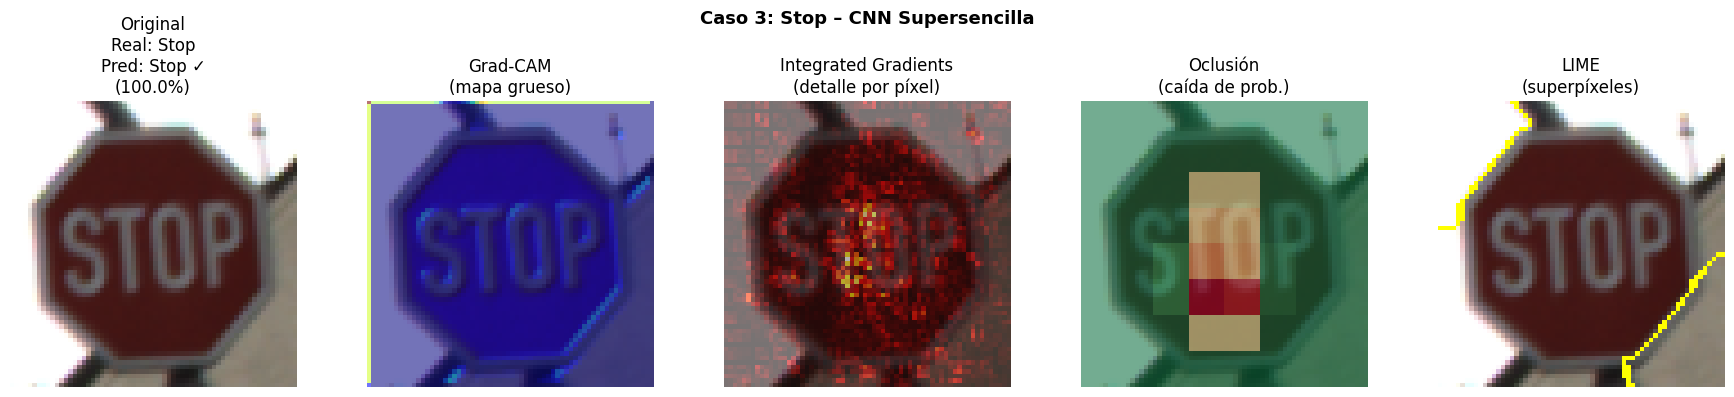


>>> CNN Simple


100%|██████████| 2000/2000 [00:20<00:00, 99.27it/s] 


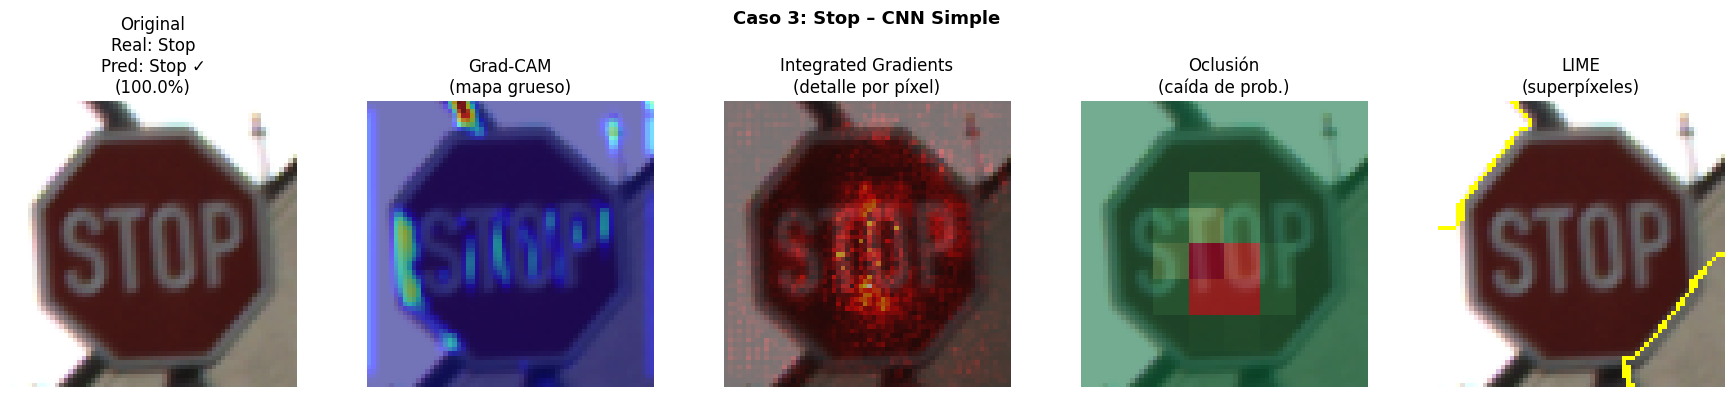


>>> CNN Compleja


100%|██████████| 2000/2000 [00:24<00:00, 82.23it/s]


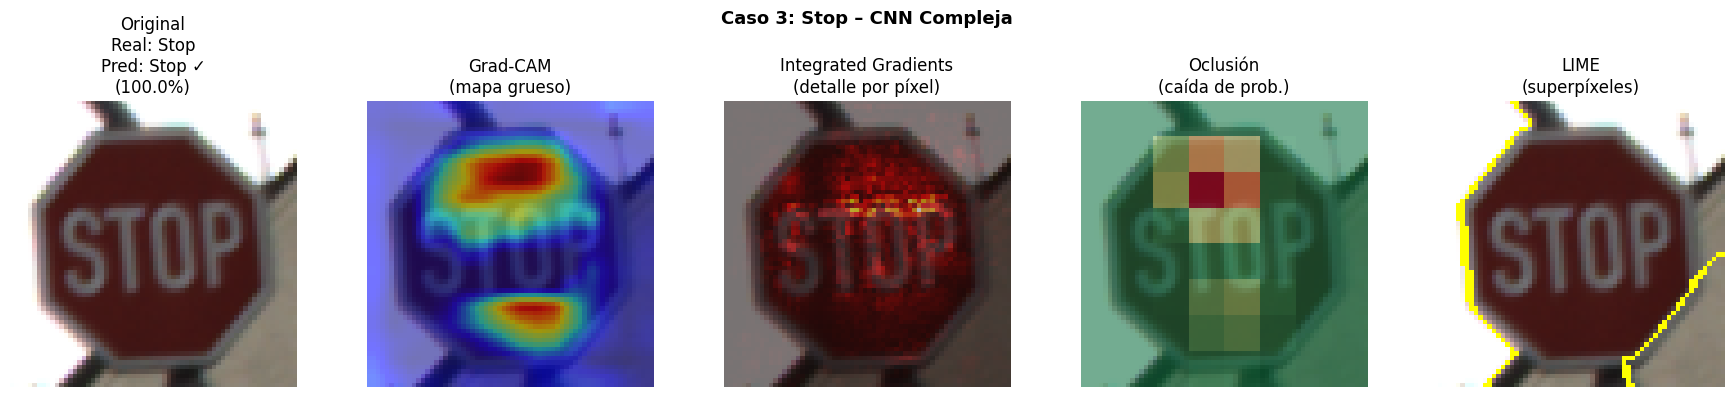


-- Oclusión manual (Stop) --

CNN Supersencilla:


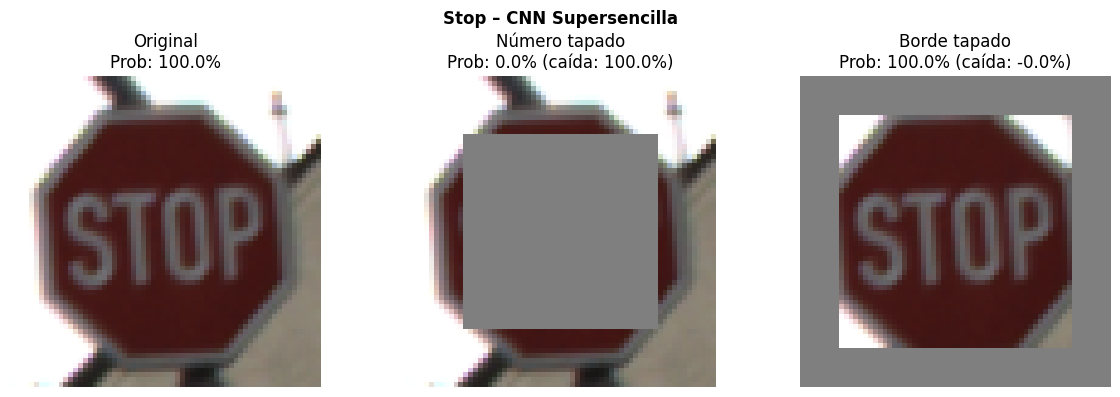

orig=100.0% | centro_tapado=0.0% (-100.0%) | borde_tapado=100.0% (--0.0%)

CNN Simple:


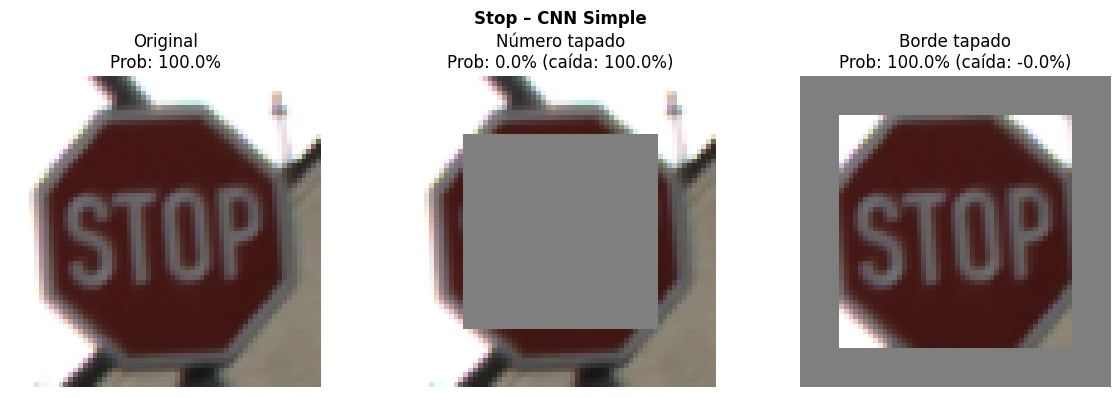

orig=100.0% | centro_tapado=0.0% (-100.0%) | borde_tapado=100.0% (--0.0%)

CNN Compleja:


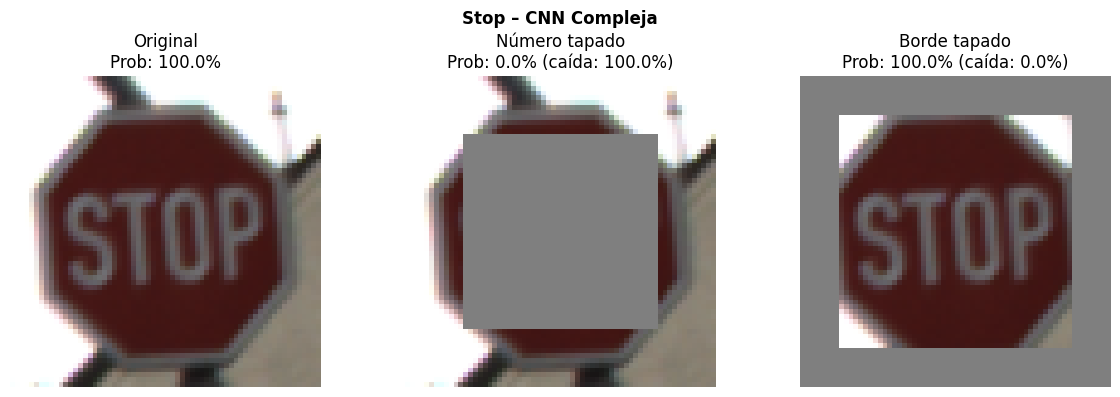

orig=100.0% | centro_tapado=0.0% (-100.0%) | borde_tapado=100.0% (-0.0%)


In [ ]:
idx_stop = CLASS_NAMES.index('Stop')
img_stop = get_sample(idx_stop, split='test', n=0)

print('CASO 3: Stop')
compare_all_models(img_stop, idx_stop, title='Caso 3: Stop')

# Prueba adicional: tapar centro (donde está STOP) vs borde (forma octogonal)
print('\n-- Oclusión manual (Stop) --')
print('\nCNN Supersencilla:')
o, n, b = occlusion_experiment(supersimple_model, img_stop, idx_stop, 'Stop – CNN Supersencilla')
print(f'orig={o:.1%} | centro_tapado={n:.1%} (-{o-n:.1%}) | borde_tapado={b:.1%} (-{o-b:.1%})')
print('\nCNN Simple:')
o, n, b = occlusion_experiment(simple_model, img_stop, idx_stop, 'Stop – CNN Simple')
print(f'orig={o:.1%} | centro_tapado={n:.1%} (-{o-n:.1%}) | borde_tapado={b:.1%} (-{o-b:.1%})')
print('\nCNN Compleja:')
o, n, b = occlusion_experiment(complex_model, img_stop, idx_stop, 'Stop – CNN Compleja')
print(f'orig={o:.1%} | centro_tapado={n:.1%} (-{o-n:.1%}) | borde_tapado={b:.1%} (-{o-b:.1%})')

#### **Conclusiones – Caso 3: Stop**

La señal de Stop tiene varias características importantes que pueden ayudar al modelo a reconocerla: el color rojo, la forma octogonal y la palabra STOP. Por eso, este caso es útil para analizar si el modelo se está fijando en el texto interior, en la forma exterior o en una combinación de ambas cosas.

En este caso, los tres modelos clasifican correctamente la imagen como Stop con una confianza muy alta. Sin embargo, las explicaciones muestran que no todos los métodos apuntan exactamente a la misma zona.

La CNN Supersencilla parece depender mucho de la zona central de la señal, pero esto se ve sobre todo en la oclusión. Cuando se tapa el centro, la confianza cae de 100% a 0%, mientras que al tapar el borde se mantiene en 100%. En Grad-CAM, en cambio, no aparece una activación clara: el mapa se ve casi todo azul y no permite localizar bien una región concreta. En Integrated Gradients sí aparece importancia en la parte central, aunque de forma bastante difusa. Por otro lado, LIME marca sobre todo zonas del contorno exterior. Por tanto, en este modelo las explicaciones no son totalmente consistentes entre sí: la oclusión apunta claramente al centro, pero LIME y Grad-CAM no muestran de forma tan limpia que el modelo esté leyendo la palabra STOP.

La CNN Simple muestra un comportamiento parecido. La oclusión indica que el centro es fundamental, porque al tapar la palabra STOP la confianza cae al 0%, mientras que tapar el borde casi no cambia la predicción. En Grad-CAM, la señal aparece mayoritariamente en azul, aunque se observan algunas activaciones pequeñas en zonas del borde y del entorno de la señal. En Integrated Gradients, la importancia vuelve a centrarse sobre la zona central, especialmente cerca de las letras. Sin embargo, LIME sigue destacando principalmente partes del contorno exterior. Esto sugiere que el modelo depende mucho del contenido central, pero algunos métodos siguen mostrando influencia de la forma general de la señal.

La CNN Compleja muestra una explicación algo más clara. En Grad-CAM, ya aparecen activaciones más visibles dentro de la señal, especialmente en zonas superiores e inferiores cercanas a la palabra STOP. En Integrated Gradients, la importancia se sitúa de forma más clara sobre los trazos de las letras, sobre todo en la zona central superior de la palabra. La oclusión confirma que tapar el centro elimina la confianza del modelo, mientras que tapar el borde casi no afecta. Aun así, LIME también marca parte del contorno exterior, por lo que el modelo no ignora completamente la forma octogonal.

En conjunto, la prueba más clara es la oclusión, ya que en los tres modelos tapar el centro hace caer la predicción a 0%, mientras que tapar el borde casi no afecta. Esto indica que la zona central de la señal es muy importante para todos ellos. Aun así, los mapas no son perfectos ni todos coinciden. Grad-CAM es poco informativo en los modelos más simples, LIME tiende a resaltar el contorno e Integrated Gradients muestra mejor la importancia del texto. Por eso, aunque los tres modelos aciertan, la CNN Compleja parece ofrecer una explicación algo más adecuada, porque sus mapas se relacionan mejor con la palabra STOP.

### **Caso 4 – Señales triangulares**

**Pregunta: Las señales triangulares (Ceda el paso, Precaución general, Obras, Peatones) tienen todas la misma forma de triángulo. La única diferencia es el símbolo que llevan dentro. ¿El modelo mira el símbolo interno o solo ve un triángulo y ya clasifica?**

Esperamos los métodos XAI resalten el interior del triángulo, donde está el símbolo específico de cada señal.

CASO 4: Señales triangulares

── Ceda el paso ──

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:22<00:00, 88.00it/s] 


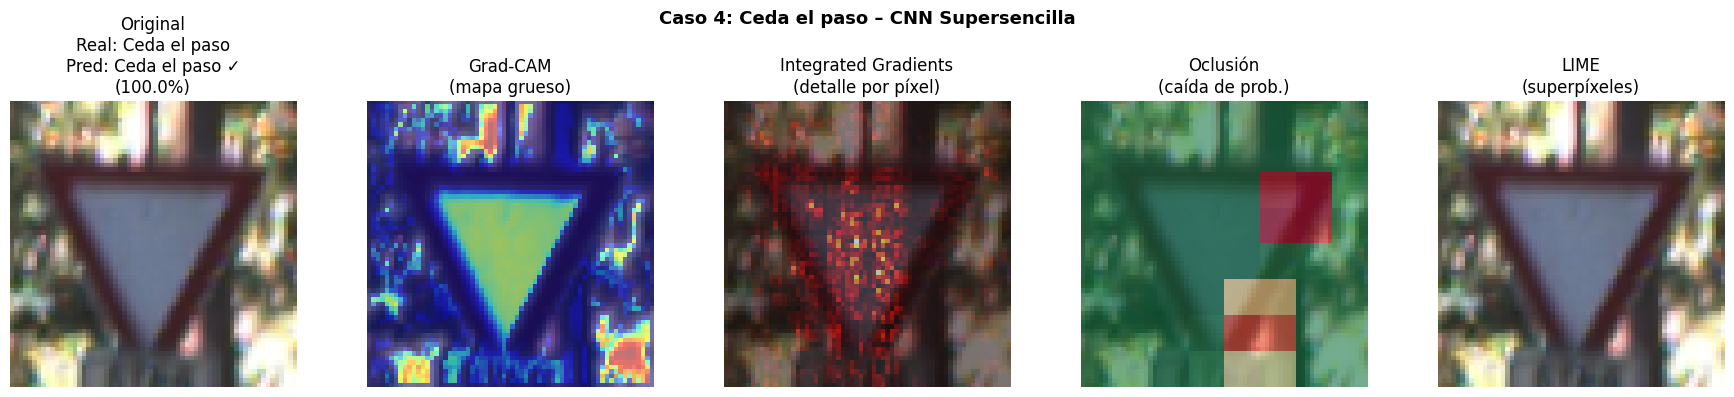


>>> CNN Simple


100%|██████████| 2000/2000 [00:21<00:00, 93.84it/s] 


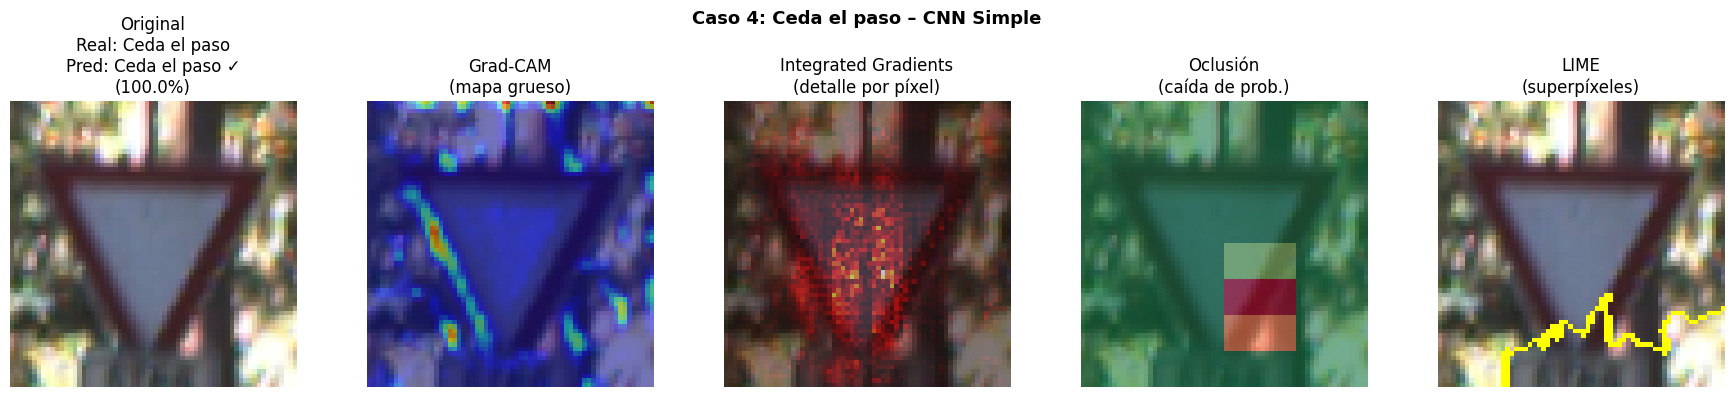


>>> CNN Compleja


100%|██████████| 2000/2000 [00:23<00:00, 83.46it/s]


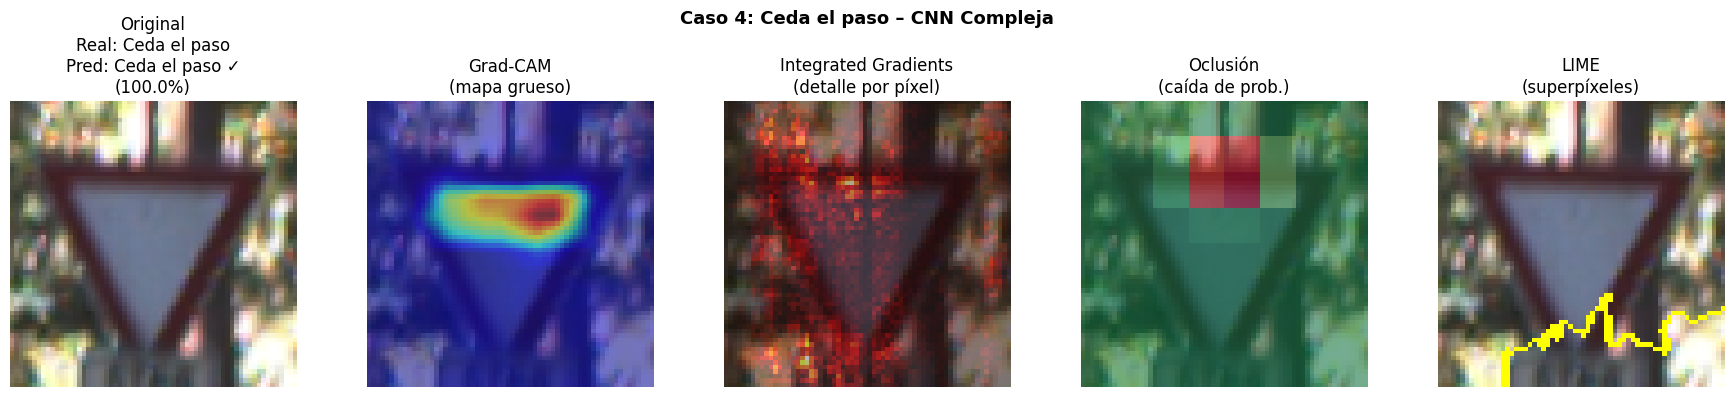


── Precaución general ──

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:20<00:00, 96.76it/s] 


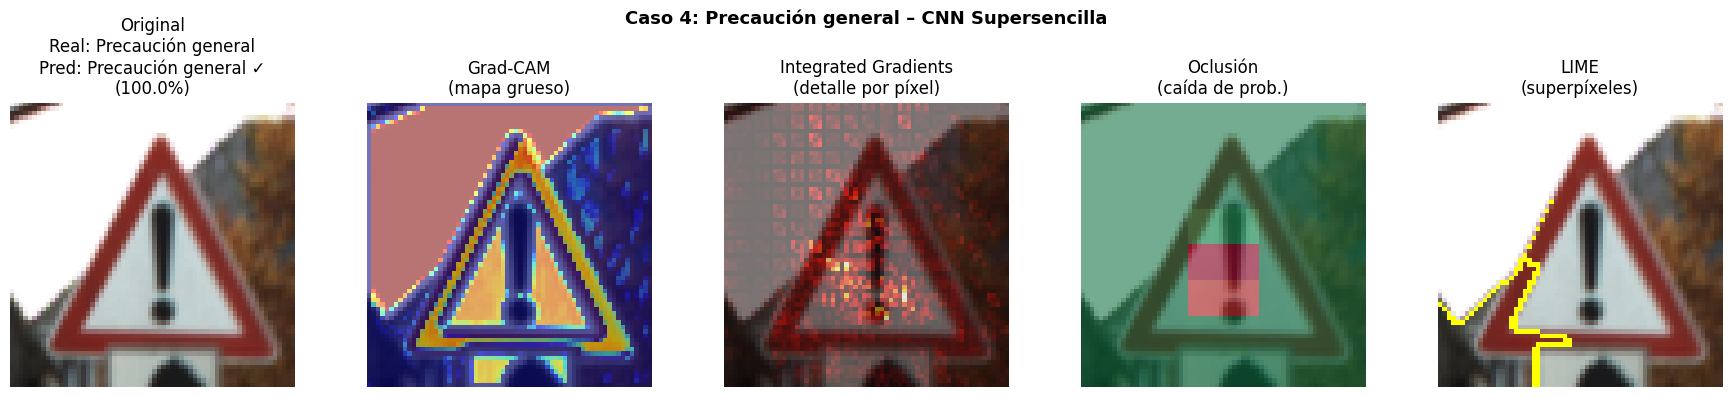


>>> CNN Simple


100%|██████████| 2000/2000 [00:20<00:00, 95.79it/s] 


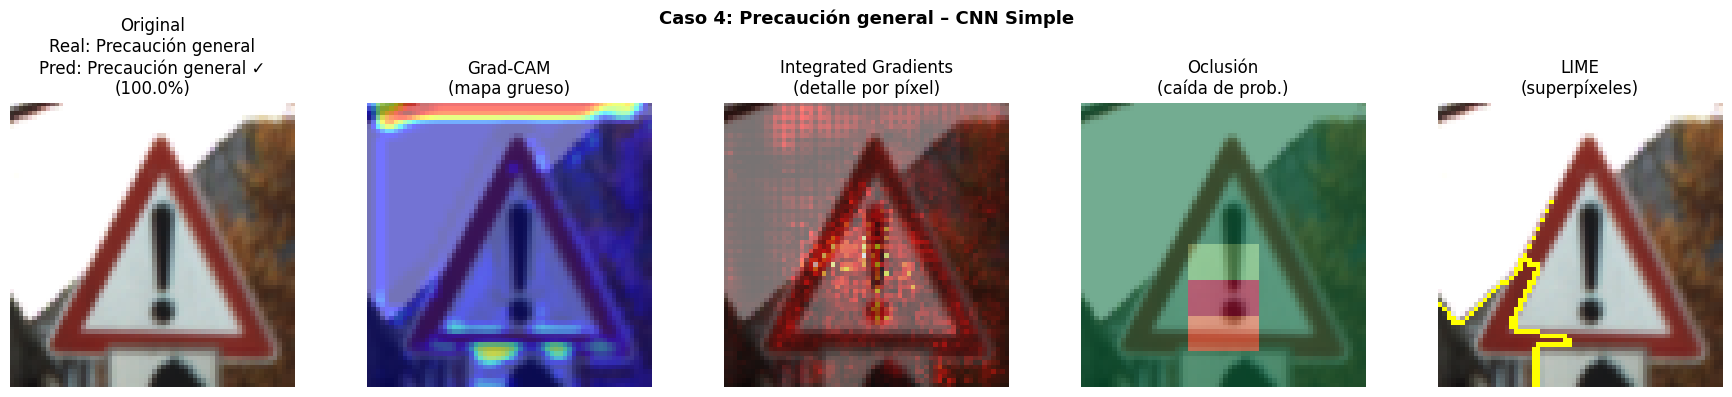


>>> CNN Compleja


100%|██████████| 2000/2000 [00:22<00:00, 87.94it/s] 


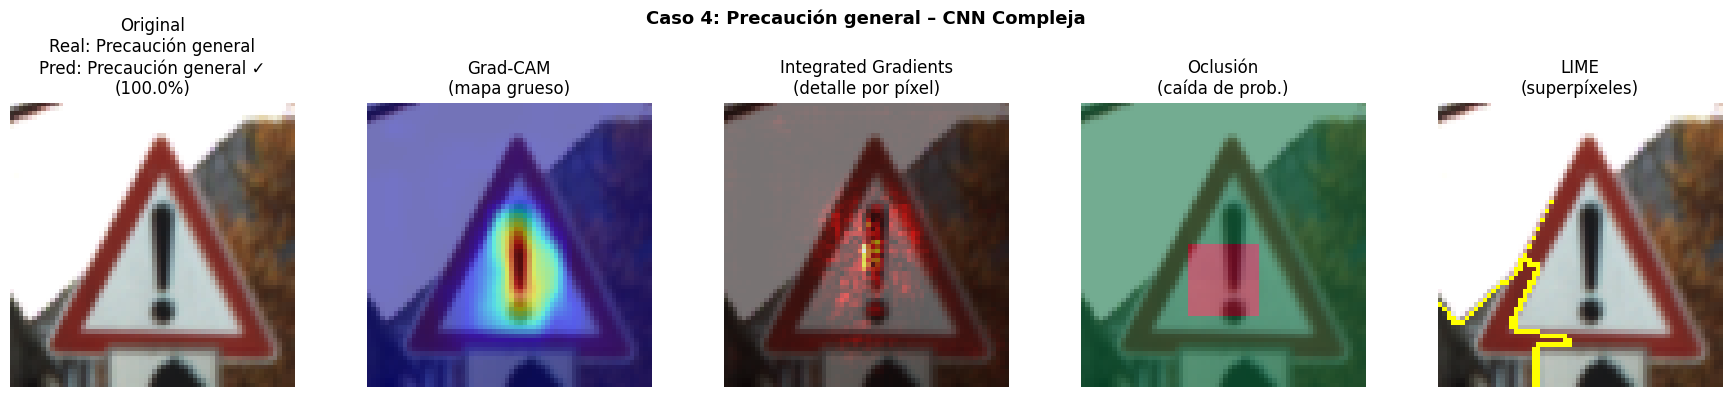


── Obras ──

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:20<00:00, 97.69it/s] 


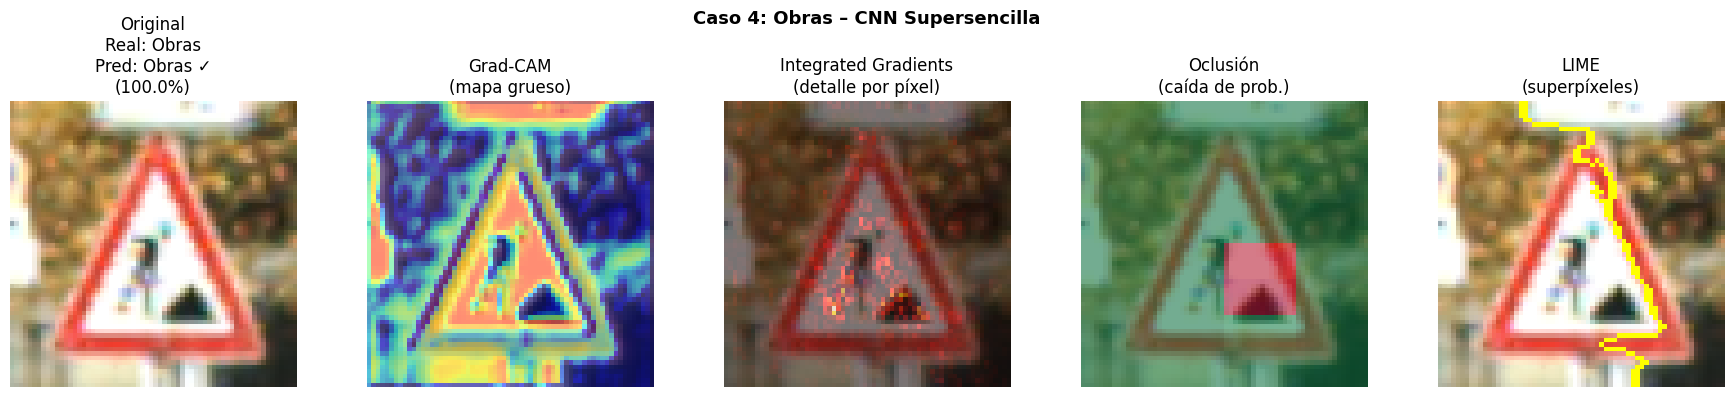


>>> CNN Simple


100%|██████████| 2000/2000 [00:20<00:00, 97.43it/s] 


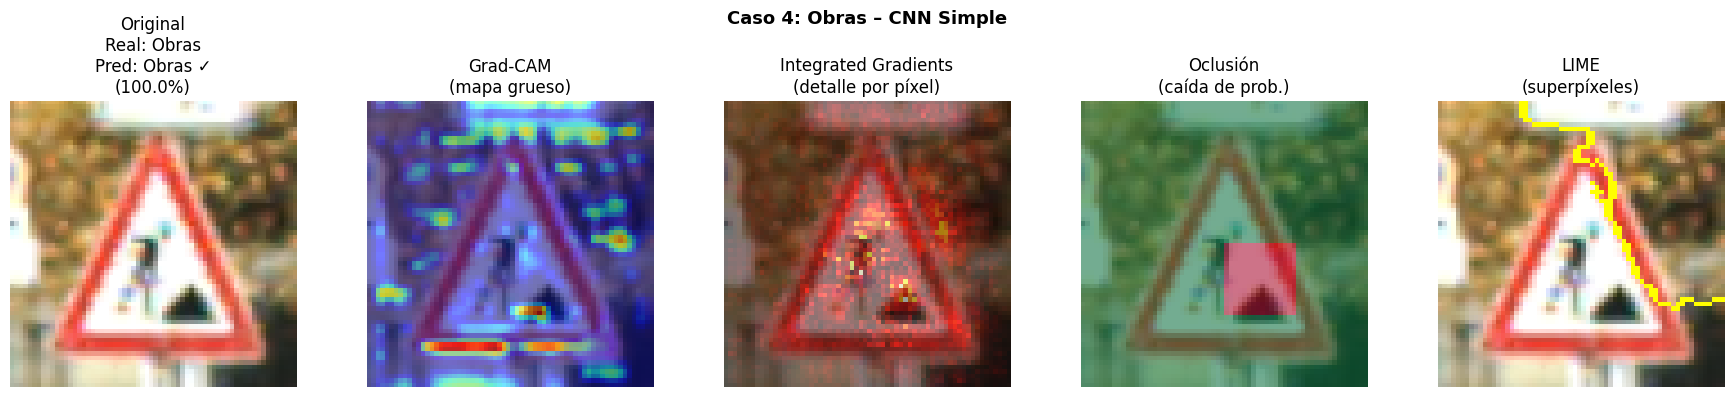


>>> CNN Compleja


100%|██████████| 2000/2000 [00:22<00:00, 90.02it/s] 


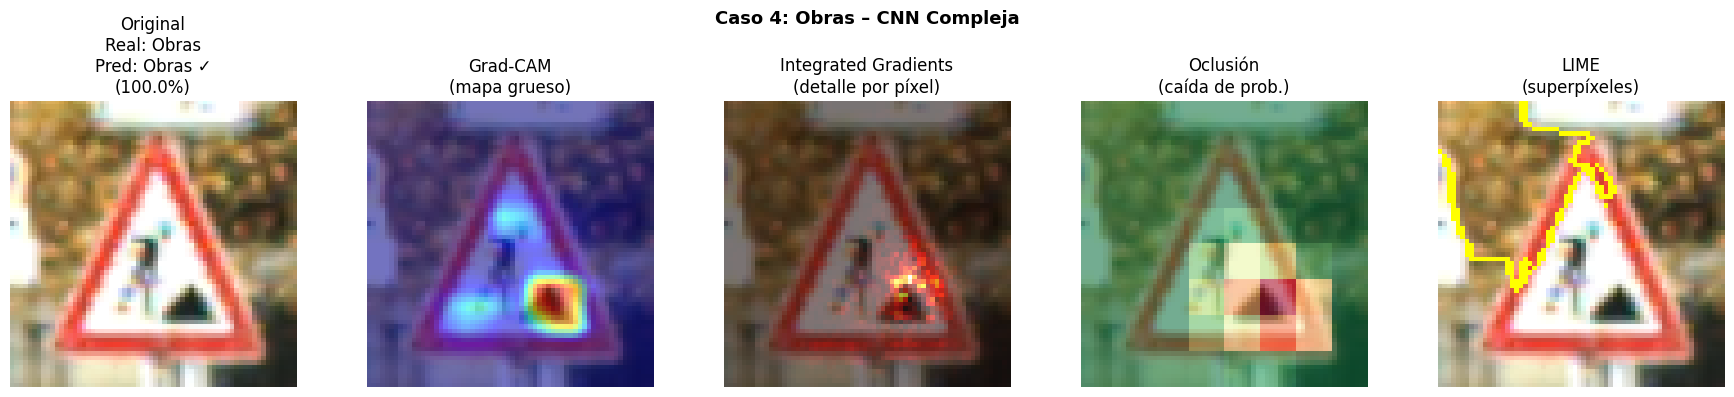


── Peatones ──

>>> CNN Supersencilla


100%|██████████| 2000/2000 [00:20<00:00, 96.85it/s] 


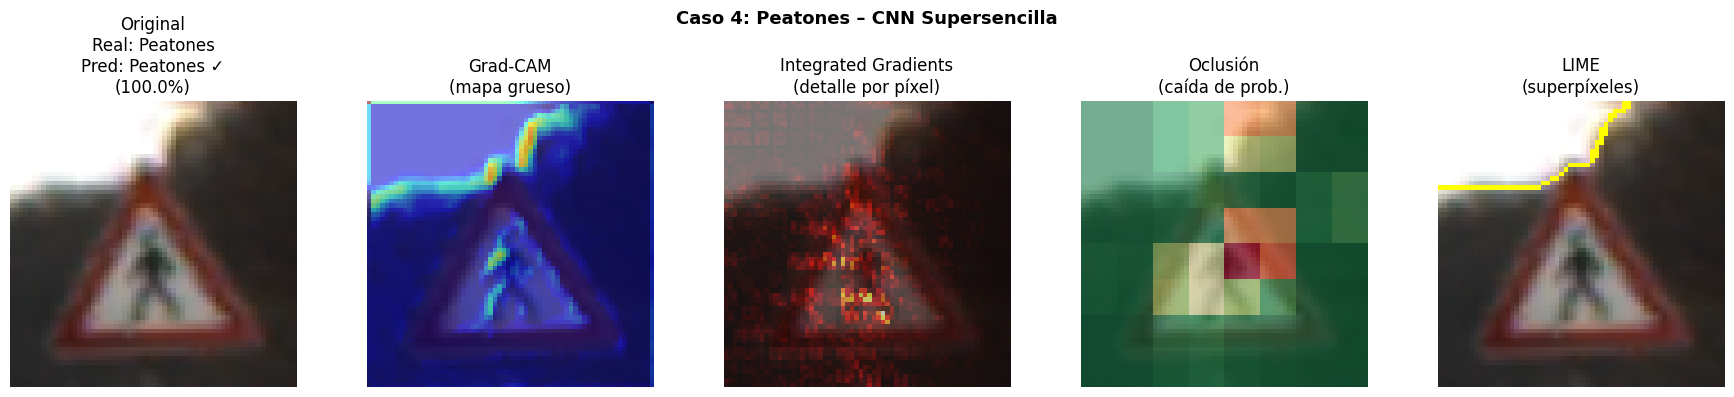


>>> CNN Simple


100%|██████████| 2000/2000 [00:20<00:00, 99.81it/s] 


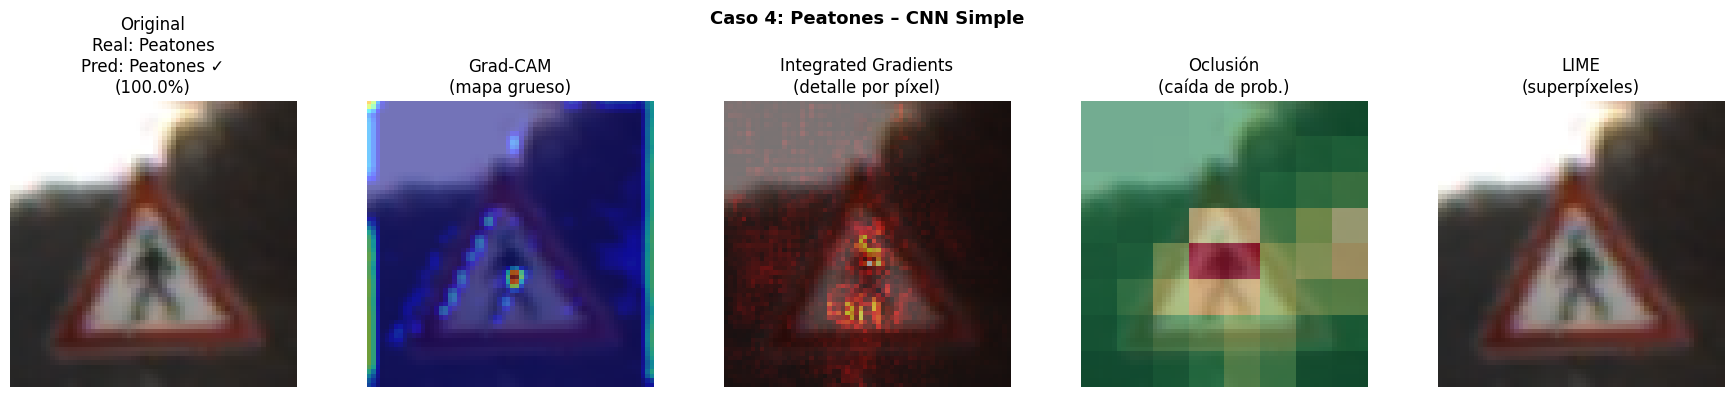


>>> CNN Compleja


100%|██████████| 2000/2000 [00:21<00:00, 92.44it/s] 


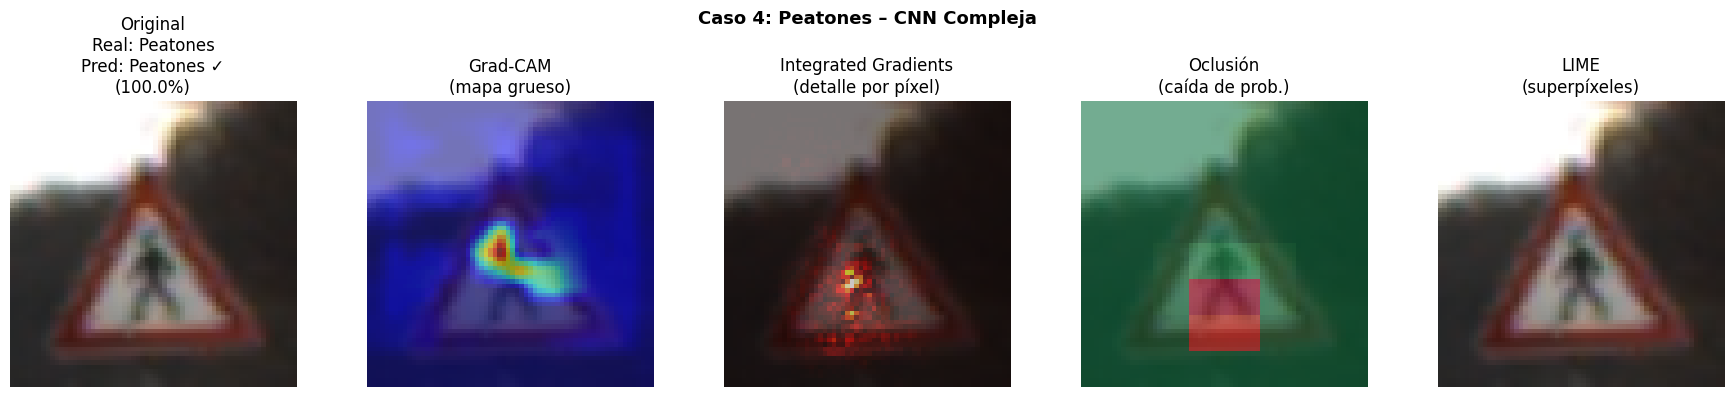

In [ ]:
triangulares = [
    ('Ceda el paso',      CLASS_NAMES.index('Ceda el paso')),
    ('Precaución general',CLASS_NAMES.index('Precaución general')),
    ('Obras',             CLASS_NAMES.index('Obras')),
    ('Peatones',          CLASS_NAMES.index('Peatones')),
]

print('CASO 4: Señales triangulares')

for name, idx in triangulares:
    img_t = get_sample(idx, split='test', n=0)
    print(f'\n── {name} ──')
    compare_all_models(img_t, idx, title=f'Caso 4: {name}')

#### Conclusiones – Caso 4: Señales triangulares


Ceda el paso, es la única señal triangular que no tiene ningún símbolo dentro: es un triángulo invertido, con solo el borde rojo. Los tres modelos la reconocen bien y los mapas XAI lo confirman. En la Supersencilla, Grad-CAM se fija en la forma general. Esto tiene sentido, porque no hay nada más que mirar: la forma del triángulo invertido ya es suficiente para identificarla. No necesita leer nada dentro, porque no hay nada. Por eso incluso el modelo más básico la acierta casi siempre.

En Precaución general, tenemos l signo de exclamación dentro del triángulo. En la CNN Supersencilla, Grad-CAM ilumina gran parte de la señal y no se centra claramente en la exclamación. Integrated Gradients también marca bastante el borde rojo y zonas amplias del triángulo. La red mira la señal de forma muy general. En la CNN Simple empieza a verse más atención hacia el centro, aunque reparte bastante importancia entre el borde y el símbolo. La CNN Compleja se concentra mucho más en la exclamación. Tanto Grad-CAM como Oclusión muestran que la zona central es la que más influye en la predicción.

En Obras aparece un patrón parecido. La señal tiene dentro la figura de un trabajador con una pala. En la CNN Supersencilla, los mapas XAI se reparten por casi todo el triángulo: Grad-CAM ilumina gran parte de la señal, Integrated Gradients marca bastante el borde rojo y LIME destaca sobre todo el contorno exterior. La red parece fijarse más en la forma del triángulo que en el trabajador. La CNN Simple mejora un poco y empieza a mirar más hacia el centro, aunque todavía de forma bastante amplia. La CNN Compleja se concentra en el trabajador y sobre todo en la pala, y Oclusión muestra que tapar esa zona es lo que más hace caer la confianza.

En Peatones es donde mejor se ve la diferencia entre modelos. En la CNN Supersencilla, Grad-CAM vuelve a aparecer muy repartido y Oclusión casi no marca ninguna zona importante. La red no se fija claramente en la persona del centro. En la CNN Simple y en la Compleja, los mapas cambian bastante: Grad-CAM se concentra sobre la figura de la persona y Oclusión marca justo la zona central como la más importante para la predicción.

La matriz de confusión confirma lo mismo. En la CNN Supersencilla, muchas señales de Peatones se clasifican como Obras. Tiene sentido, porque las dos señales son triángulos rojos con una figura humana dentro. Si la red no mira bien el símbolo interior, ambas señales le parecen casi iguales.

Los cuatro métodos XAI aunque funcionan de forma distinta, todos llegan a la misma idea: los modelos simples dependen más de la forma triangular y del borde, mientras que el modelo complejo utiliza el símbolo interior. Este caso es parecido a lo que ocurría con las señales de velocidad. Cuando varias señales tienen la misma forma y el mismo color, el detalle importante está dentro de la señal. La CNN Supersencilla no consigue separar bien estos detalles y por eso usa reglas más generales. La CNN Compleja, sí lo consigue y por ello se reducen mucho los errores entre señales parecidas.

### **Caso 5 – Perturbaciones diseñadas**

**Pregunta: ¿Qué parte de la señal es suficiente para que el modelo mantenga la predicción?**

Diseñamos siete perturbaciones sobre las mismas imágenes:

1. Tapar el número – ¿Sin número, sigue clasificando?
2. Tapar el borde– ¿Sin borde, sigue clasificando?
3. Escala de grises – ¿Sin color, sigue clasificando?
4. Blur (desenfoque) – ¿Con la imagen borrosa, sigue clasificando?
5. Oscurecer – ¿De noche o con poca luz, sigue clasificando?
6. Ruido – ¿Con ruido añadido, sigue clasificando?
7. Recorte – ¿Si la señal está cortada en los bordes, sigue clasificando?

Para cada perturbación medimos la probabilidad de la clase correcta. Cuanto más cae, más importante es esa región o característica.

CASO 5: Perturbaciones diseñadas

=== Límite 30 – CNN Supersencilla ===


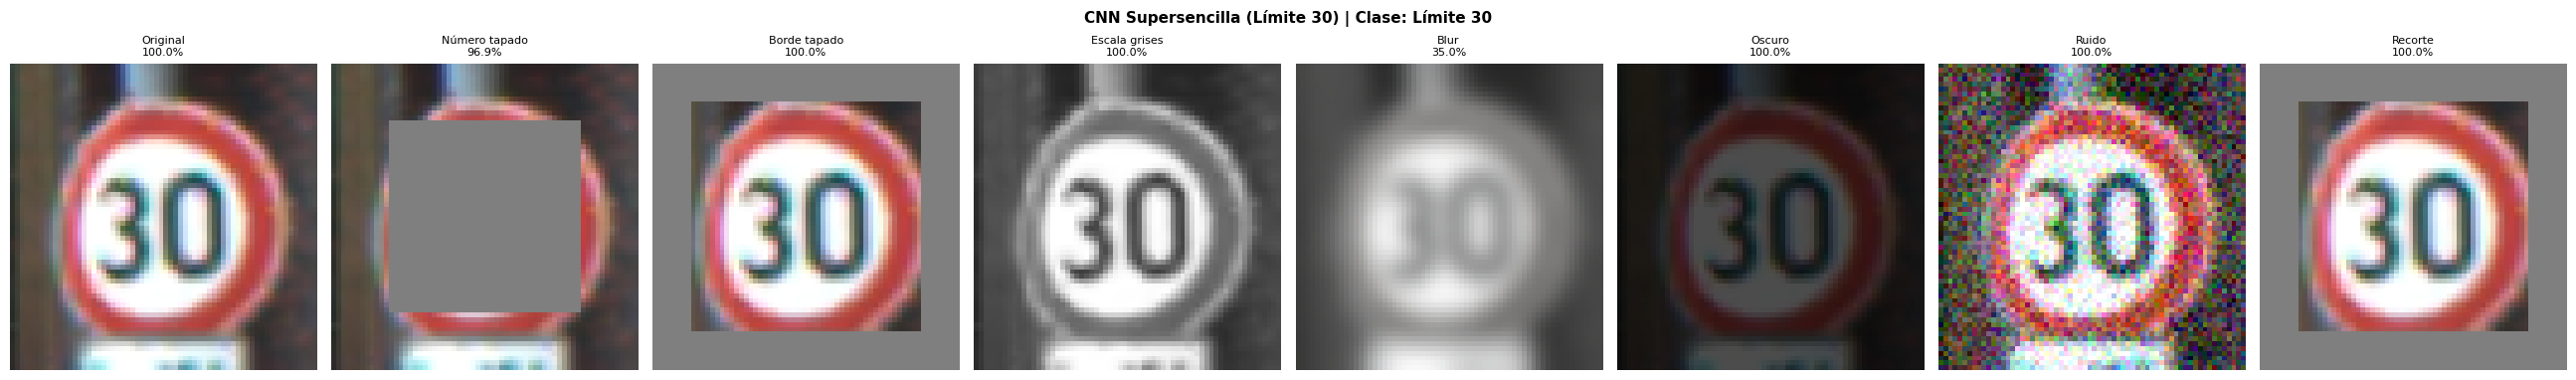

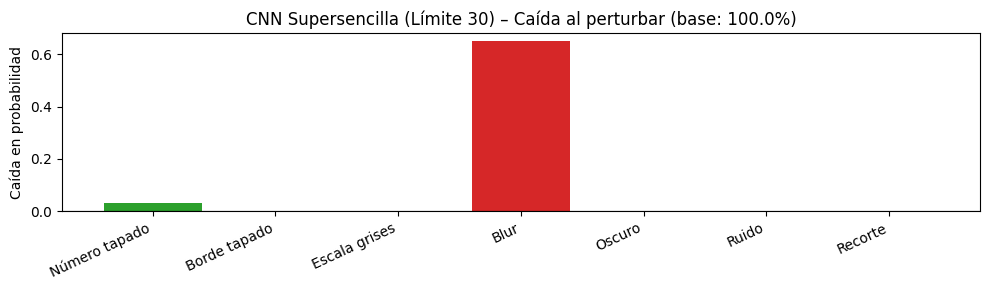


=== Límite 30 – CNN Simple ===


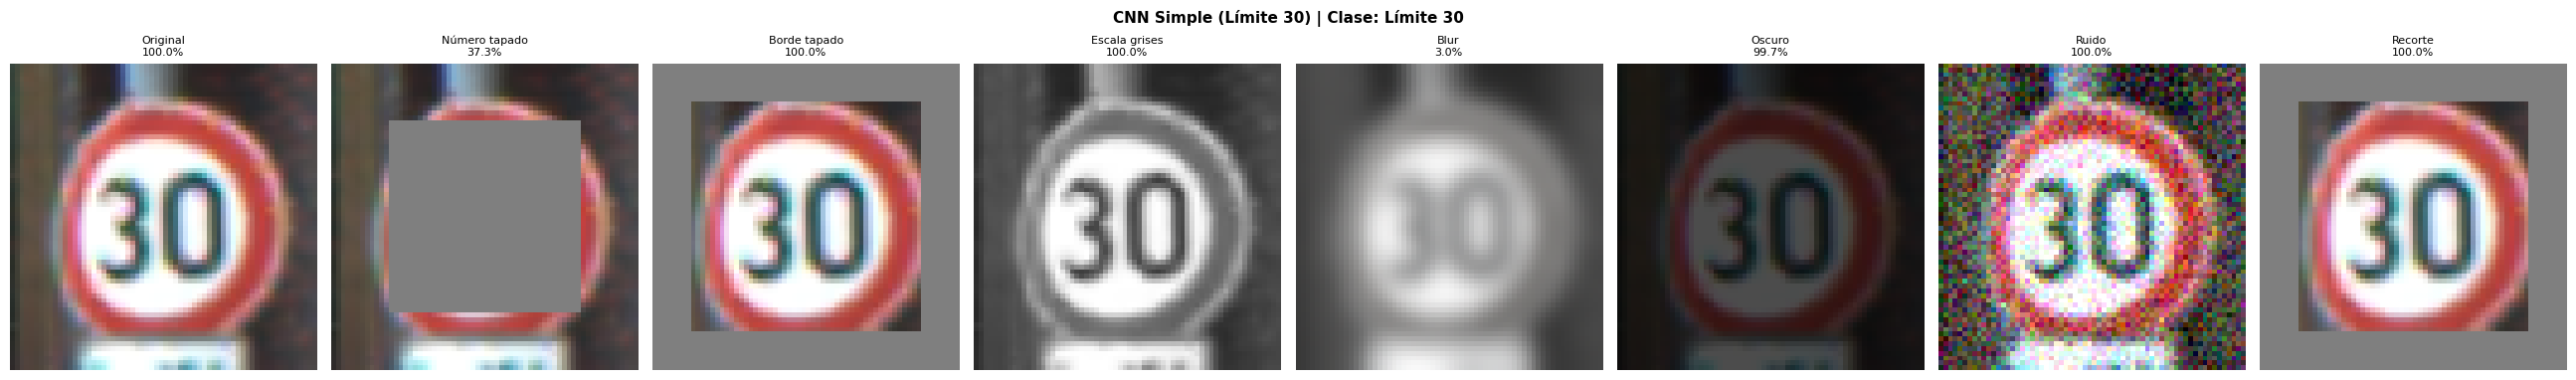

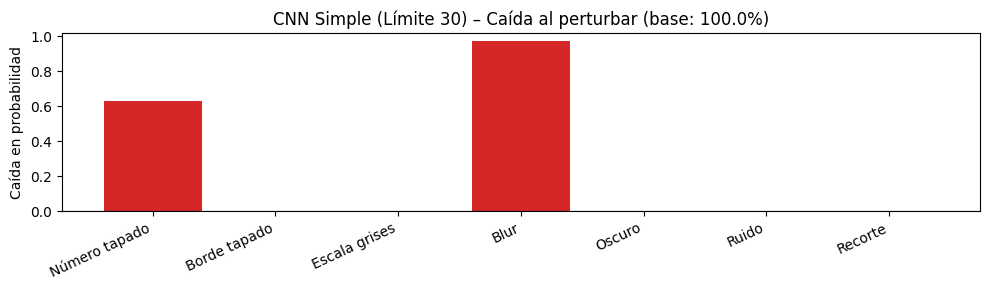


=== Límite 30 – CNN Compleja ===


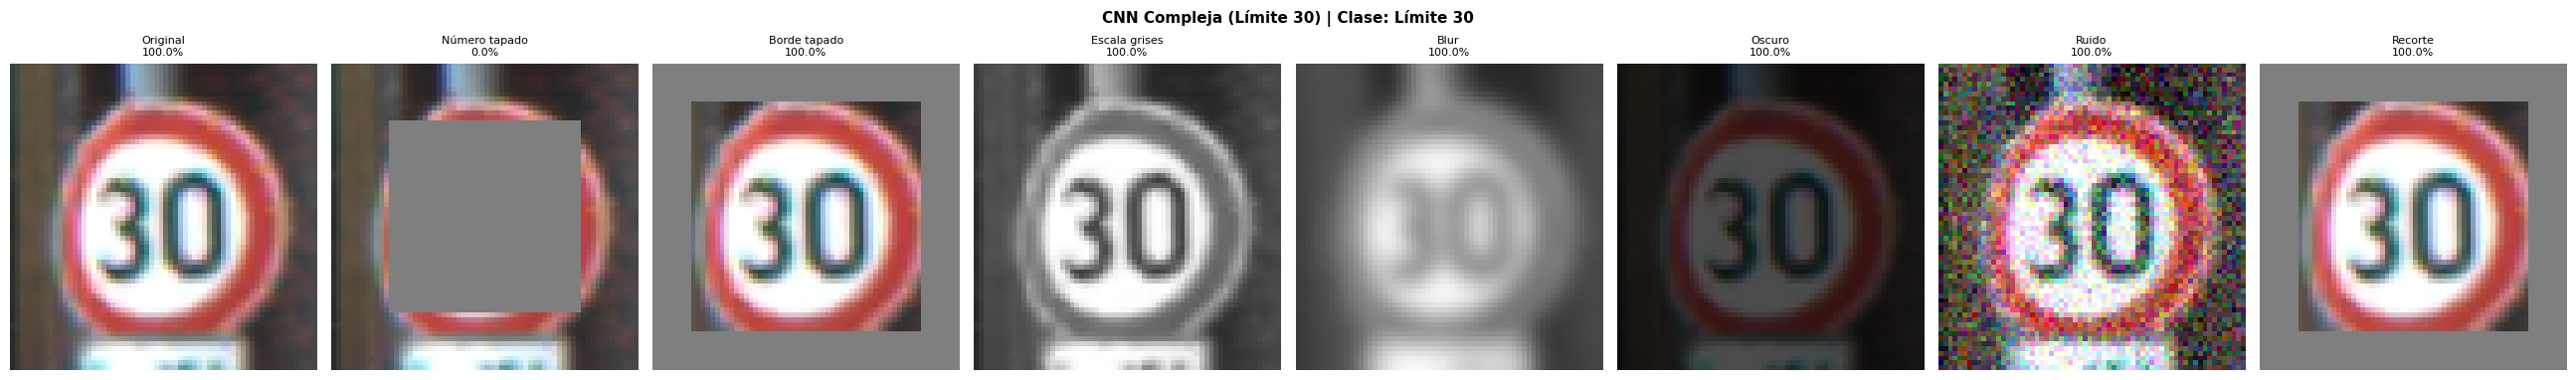

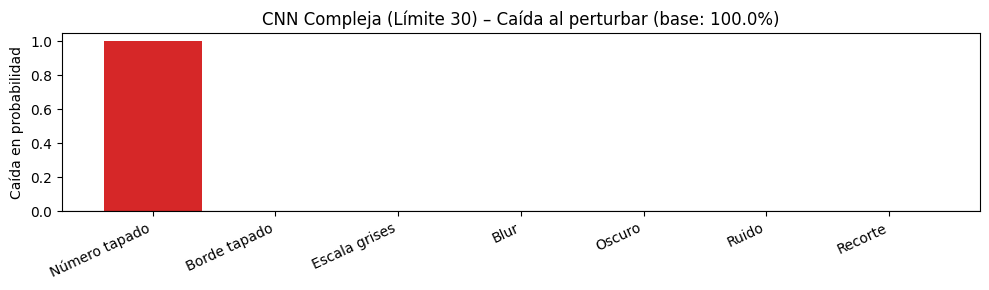


=== Stop – CNN Supersencilla ===


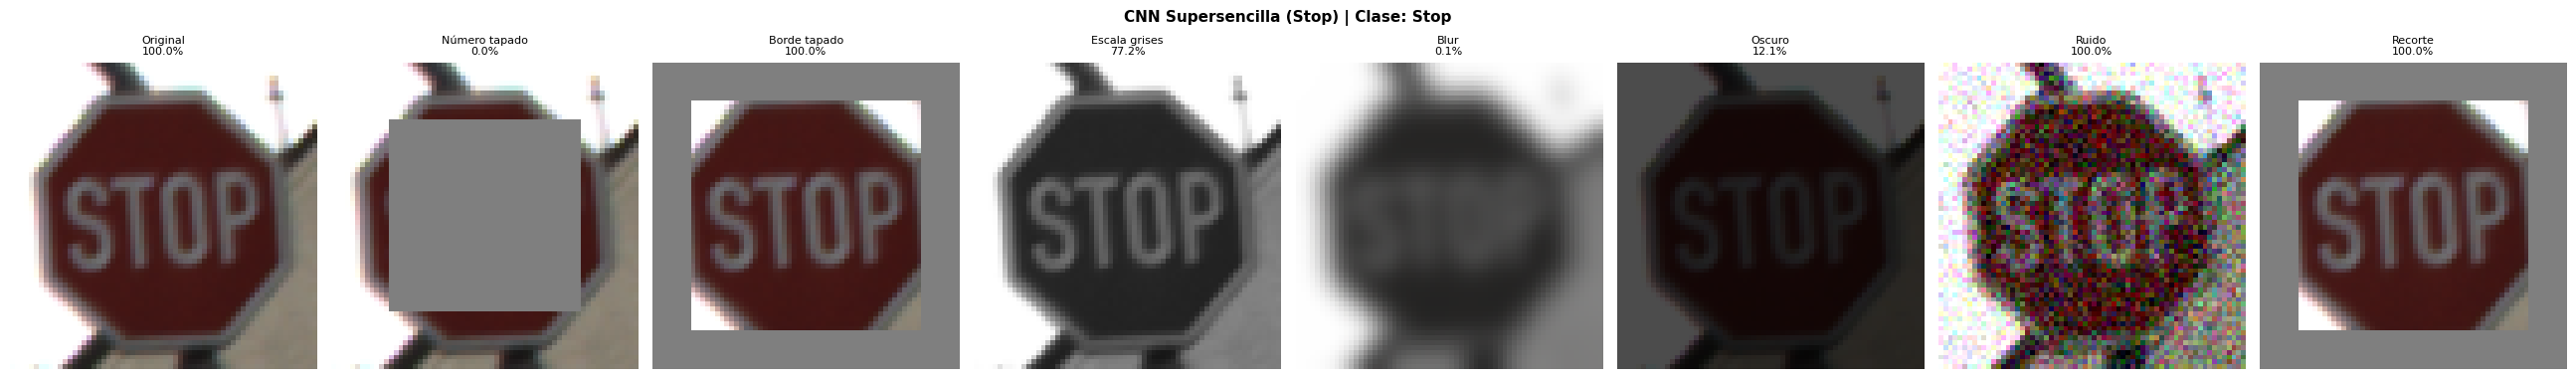

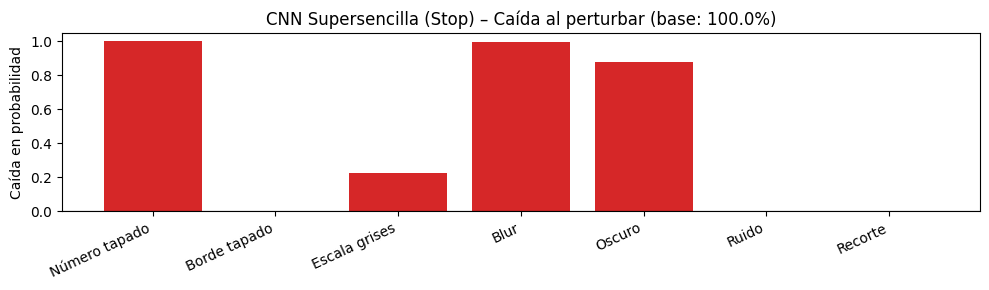


=== Stop – CNN Simple ===


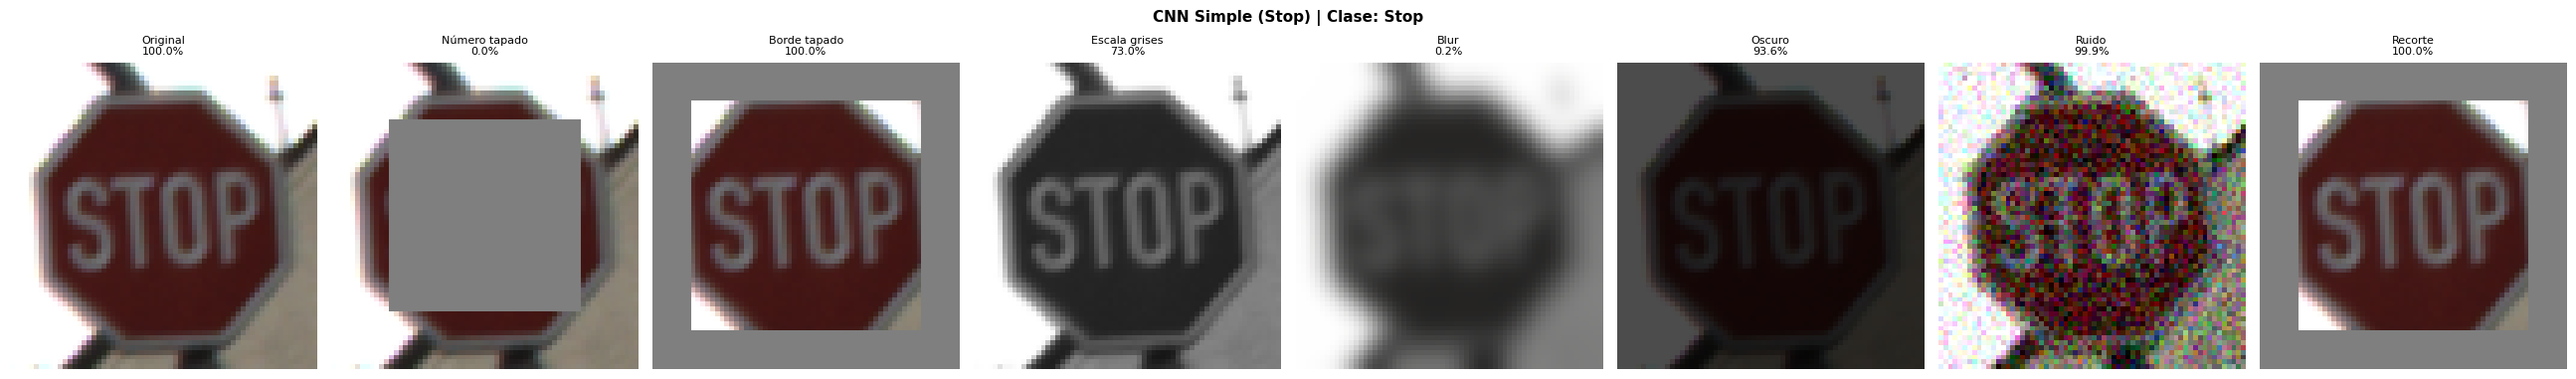

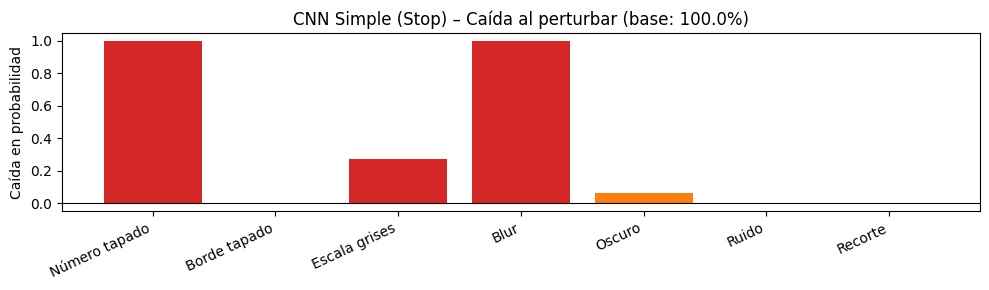


=== Stop – CNN Compleja ===


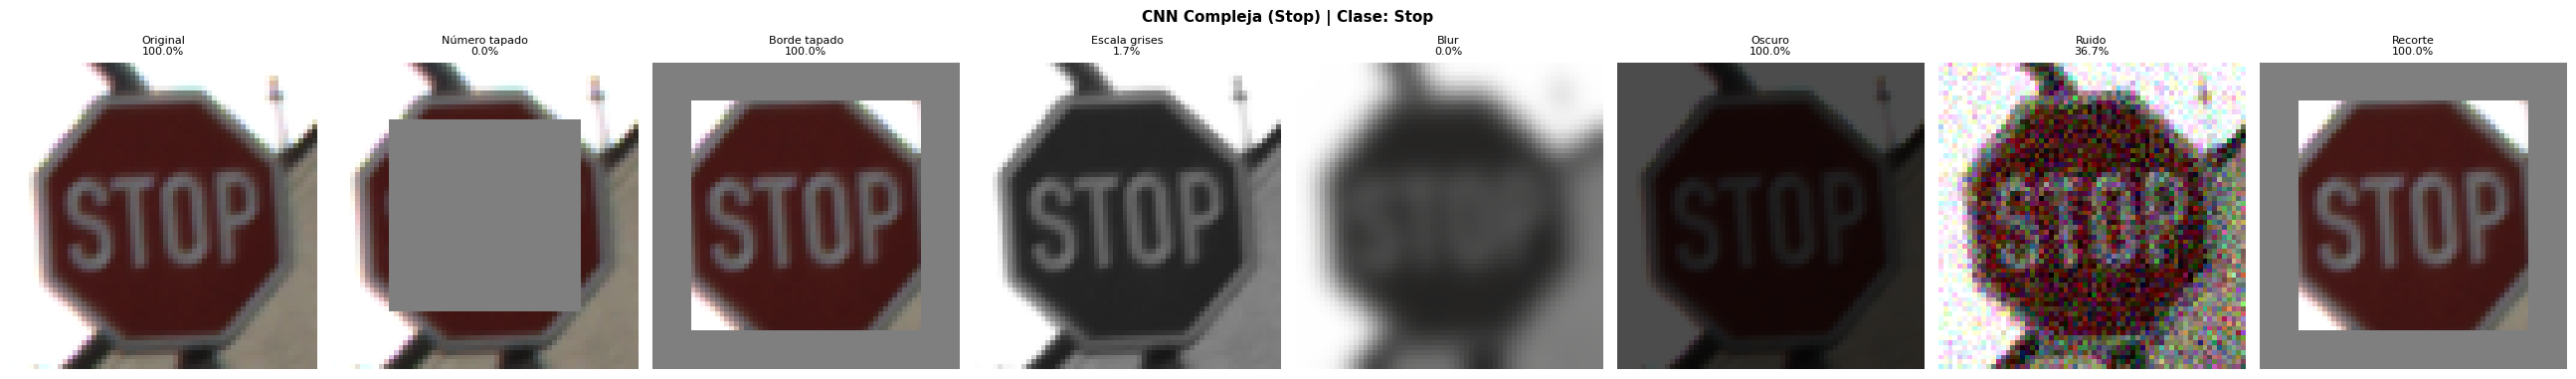

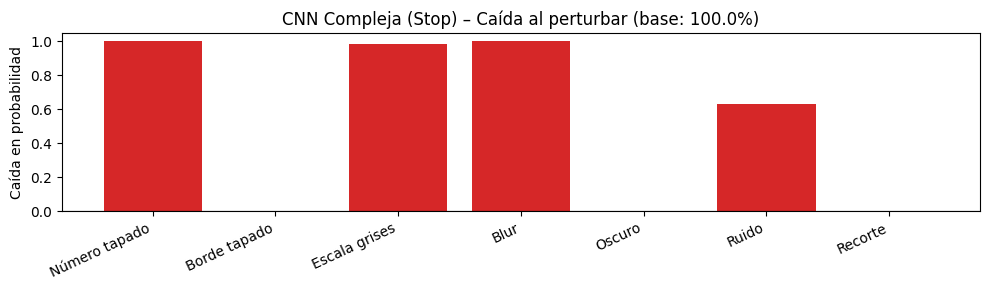

In [ ]:
from scipy.ndimage import gaussian_filter

def perturb(img, mode):
    out = img.copy()
    H, W = img.shape[:2]
    m = H // 5
    b = max(H // 8, 4)
    if mode == 'number':
        out[m: H-m, m: W-m] = 0.5
    elif mode == 'border':
        out[:b,:]=out[-b:,:]=out[:,:b]=out[:,-b:]=0.5
    elif mode == 'gray':
        g = out.mean(axis=-1, keepdims=True)
        out = np.repeat(g, 3, axis=-1)
    elif mode == 'blur':
        out = gaussian_filter(out, sigma=2.5)
    elif mode == 'dark':
        out = np.clip(out * 0.3, 0, 1)
    elif mode == 'noise':
        noise = np.random.normal(0, 0.12, out.shape).astype(np.float32)
        out   = np.clip(out + noise, 0, 1)
    elif mode == 'crop':
        c = H // 8
        out[:c,:]=out[-c:,:]=out[:,:c]=out[:,-c:]=0.5
    return out.astype(np.float32)


MODES = {
    'Original':      None,
    'Número tapado': 'number',
    'Borde tapado':  'border',
    'Escala grises': 'gray',
    'Blur':          'blur',
    'Oscuro':        'dark',
    'Ruido':         'noise',
    'Recorte':       'crop',
}


def perturbation_study(model, img, true_idx, model_name):
    results = {}
    imgs_shown = []
    labels_shown = []
    for label, mode in MODES.items():
        p_img = img if mode is None else perturb(img, mode)
        p     = float(model.predict(p_img[np.newaxis], verbose=0)[0, true_idx])
        results[label] = p
        imgs_shown.append(p_img)
        labels_shown.append(f'{label}\n{p:.1%}')

    # Mostrar imágenes perturbadas
    fig, axes = plt.subplots(1, len(MODES), figsize=(26, 4))
    for ax, pimg, lbl in zip(axes, imgs_shown, labels_shown):
        ax.imshow(pimg)
        ax.set_title(lbl, fontsize=8)
        ax.axis('off')
    fig.suptitle(f'{model_name} | Clase: {CLASS_NAMES[true_idx]}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Gráfico de barras
    fig, ax = plt.subplots(figsize=(10, 3))
    orig_p  = results['Original']
    drops   = {k: orig_p - v for k, v in results.items() if k != 'Original'}
    colors  = ['#d62728' if d > 0.15 else '#ff7f0e' if d > 0.05 else '#2ca02c' for d in drops.values()]
    ax.bar(drops.keys(), drops.values(), color=colors)
    ax.set_ylabel('Caída en probabilidad')
    ax.set_title(f'{model_name} – Caída al perturbar (base: {orig_p:.1%})')
    ax.axhline(0, color='k', linewidth=0.8)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()
    return results


# Elegimos Límite 30 y Stop como ejemplos del caso 5
test_cases_5 = [
    (img_30,   CLASS_NAMES.index('Límite 30'), 'Límite 30'),
    (img_stop, CLASS_NAMES.index('Stop'),      'Stop'),
]

print('CASO 5: Perturbaciones diseñadas')
for img_x, idx_x, name in test_cases_5:
    print(f'\n=== {name} – CNN Supersencilla ===')
    perturbation_study(supersimple_model, img_x, idx_x, f'CNN Supersencilla ({name})')
    print(f'\n=== {name} – CNN Simple ===')
    perturbation_study(simple_model,  img_x, idx_x, f'CNN Simple ({name})')
    print(f'\n=== {name} – CNN Compleja ===')
    perturbation_study(complex_model, img_x, idx_x, f'CNN Compleja ({name})')

#### **Conclusiones – Caso 5: Perturbaciones diseñadas**

En este caso se analiza cómo cambia la probabilidad de la clase correcta cuando modificamos la imagen de distintas formas. La idea es sencilla, si una perturbación hace caer mucho la probabilidad, significa que esa información era importante para el modelo.

Para Límite 30, se observa que los tres modelos mantienen la predicción cuando se tapa el borde, se pasa la imagen a escala de grises, se oscurece, se añade ruido o se recorta. Por tanto, el borde y el color no parecen ser imprescindibles en esta imagen concreta. La diferencia principal aparece al tapar el número y al aplicar blur. La CNN Supersencilla apenas baja cuando se tapa el número, pero sí cae bastante con el desenfoque. La CNN Simple cae de forma clara al tapar el número y todavía más con blur. La CNN Compleja es la más dependiente del número, ya que al taparlo la probabilidad cae a 0%, pero aguanta muy bien el resto de perturbaciones. Esto encaja con lo visto en los mapas XAI, donde los modelos más complejos parecían prestar más atención a los dígitos.

En el caso de Stop, el comportamiento es distinto. En los tres modelos, tapar la zona central donde está la palabra STOP hace caer la probabilidad a 0%, mientras que tapar el borde prácticamente no afecta. Esto indica que, para esta imagen, la información central es muy importante. La forma octogonal por sí sola no parece suficiente cuando se elimina el texto interior. Además, el blur también afecta mucho a los tres modelos, especialmente porque pone borrosa la palabra STOP. La escala de grises reduce algo la confianza en la Supersencilla y la Simple, pero en la Compleja provoca una caída mucho mayor. El ruido afecta poco a la Supersencilla y a la Simple, pero sí reduce bastante la confianza de la Compleja. En cambio, el recorte apenas cambia la predicción en los tres casos.

En conjunto, las perturbaciones muestran que los modelos no utilizan exactamente las mismas pistas en las dos señales. Para Límite 30, la CNN Compleja depende mucho del número y es bastante robusta ante cambios de color, ruido, oscuridad o recorte. Para Stop, los tres modelos dependen mucho de la zona central donde aparece el texto, ya que al taparla todos fallan. Por tanto, este caso confirma que mirar solo la accuracy no es suficiente. Todos los modelos aciertan la imagen original, pero las perturbaciones permiten ver qué información necesita realmente cada uno para mantener la predicción.

##### Resumen comparativo

| Perturbación           | Límite 30                                  | Stop                                        |
| ---------------------- | ------------------------------------------ | ------------------------------------------- |
| Número / centro tapado | Afecta mucho, sobre todo a la CNN Compleja | Afecta muchísimo a los tres modelos         |
| Borde tapado           | No afecta                                  | No afecta                                   |
| Escala de grises       | No afecta                                  | Afecta más, especialmente a la CNN Compleja |
| Blur                   | Afecta bastante                            | Afecta bastante a los tres modelos          |
| Oscuro                 | No afecta                                  | Afecta sobre todo a la CNN Supersencilla    |
| Ruido                  | No afecta                                  | Afecta sobre todo a la CNN Compleja         |
| Recorte                | No afecta                                  | No afecta                                   |



Esta tabla resume que, en Límite 30, la perturbación más importante es tapar el número, mientras que en Stop lo que más afecta es tapar la zona central donde aparece la palabra STOP.




## 5. Discusión y Conclusiones

La idea principal de este trabajo es que un modelo puede acertar sin estar usando la información correcta. Los tres modelos que hemos entrenado consiguen accuracys altos (91,4 %, 96,4 % y 99,0 %), y si solo mirásemos esos números, pensariamos que los tres funcionan bastante bien. Pero al entender el proceso interno de las redes con los métodos de explicabilidad, vemos que cada modelo llega a sus predicciones por caminos distintos, y que algunos de esos caminos son problemáticos.

Lo que hemos visto en todos los casos es que los modelos no solo se diferencian en el porcentaje de acierto, sino también en las partes de la imagen que usan para decidir. La CNN Supersencilla, con un solo bloque de convolución y un MaxPooling muy agresivo, solo es capaz de captar rasgos grandes y generales como la forma de la señal o el color. Esto le sirven para reconocer señales que son únicas por su forma, como el Stop, pero no le sirven cuando varias señales comparten la misma forma y el mismo color. Por eso confunde el 50 con el 30, y el peatón con el trabajador de obras.

La CNN Simple funciona mejor que la Supersencilla. Al tener dos bloques de convolución, ya empieza a fijarse más en el interior de la señal y por eso confunde menos las clases parecidas. Aun así, todavía no lo hace siempre bien. En algunas señales mira el número o el símbolo, pero en otras sigue usando pistas más generales, como la forma o el color. Por eso se queda en un punto intermedio entre la Supersencilla y la Compleja.

La CNN Compleja es la que mejor separa todas las clases, y las explicaciones XAI muestran que lo hace mirando las partes correctas, los símbolos interiores en las señales. Al tapar esas zonas, la confianza del modelo cae a cero, confirmando que de verdad las necesita para decidir. Esto era esperable, porque tiene tres bloques de convolución, normalización y regularización, lo que le permite analizar detalles más específicos de la imagen.


### ¿Qué aportan los métodos XAI?

Los cuatro métodos que hemos usado responden a la misma pregunta "¿en qué se fija el modelo?" pero cada uno lo hace de forma distinta y con distintas ventajas.

Grad-CAM es rápido y muy visual, nos da un mapa de calor que muestra las zonas más importantes según la última capa de convolución. Vemos que es útil para ver el patrón general, pero en los modelos más simples produce mapas poco informativos, como hemos visto en el caso del Stop con la Supersencilla, donde el mapa salía casi todo azul.

Integrated Gradients da más detalle porque trabaja píxel a píxel. Es el método que mejor marca los trazos concretos del número o del símbolo, sobre todo en la CNN Compleja. Su limitación es que depende de la imagen base (en nuestro caso una imagen negra), y con otra base los resultados podrían cambiar.

La Oclusión es el método más directo y fácil de entender. Tapa zonas y mide cuánto baja la confianza. Ha sido el método que ha dado las conclusiones más claras en todos los casos, especialmente en el caso de tapar el número en las señales de velocidad. Su problema es que el resultado depende del tamaño del parche y este puede variar entre imágenes. Si el parche es muy pequeño, puede no tapar suficiente, pero si es muy grande, puede ocultar varias partes importantes a la vez.Además, como no todas las señales aparecen en la misma posición o con el mismo tamaño, la zona tapada puede afectar de forma distinta en cada imagen.

LIME es el método que menos ha aportado en nuestro análisis. En casi todos los casos y en los tres modelos, LIME ha marcado sobre todo el contorno exterior de la señal, sin distinguir bien el contenido interior. Esto se debe a que trabaja con superpíxeles, y en imágenes pequeñas de 64x64 esos superpíxeles son grandes y no se ajustan bien a los detalles finos. Además, al usar perturbaciones aleatorias, sus resultados cambian de una ejecución a otra, lo que le da poca estabilidad.

Loss métodos no siempre muestran lo mismo. Pero cuando varios coinciden en la misma idea, la conclusión es más segura. Por eso es útil usar más de un método, cada uno tiene sus fallos, pero juntos ayudan a entender mejor al modelo.

En conjunto, esta parte del trabajo demuestra por qué la explicabilidad es útil. Aunque esperabamos que la CNN Compleja funcionara mejor que la Supersencilla, los métodos XAI nos han permitido verlo de forma práctica. No solo sabemos qué modelo acierta más, sino también qué zonas usa cada uno para tomar sus decisiones.

Gracias a esto, hemos visto que los modelos simples se apoyan más en rasgos generales y el modelo complejo se centra mejor en detalles importantes. Esta diferencia no se ve claramente solo con el accuracy. Por eso, la explicabilidad ayuda a entender el comportamiento del modelo, detectar errores y comprobar si sus decisiones tienen sentido.

### ¿Qué implica esto para la conducción autónoma?
Estos resultados muestran que un modelo puede cometer errores importantes si se fija en pistas incorrectas. Por ejemplo, puede confundir una señal de 50 con una de 30 si no lee bien el número. En un coche autónomo, esto sería un problema grave, porque podría tomar una decisión equivocada con mucha confianza.

Además, en la carretera real las señales no siempre aparecen perfectas. Pueden estar sucias, tapadas, desgastadas o verse mal por la luz, la lluvia o el movimiento. Si un modelo ya falla con imágenes claras, en estas condiciones puede fallar todavía más.

Por eso, la explicabilidad es importante antes de usar un modelo en un sistema real. Nos permite ver si el modelo está mirando la parte correcta de la señal o si está usando atajos que pueden provocar estos errores.

### Respuesta a las preguntas preliminares iniciales.

Al principio del trabajo planteamos seis preguntas. Después de analizar los cuatro casos, podemos responderlas.

La primera pregunta era si el modelo mira la parte correcta de cada señal. La respuesta depende del modelo. La CNN Compleja es la que se fija de forma más clara en el contenido interior de la señal.

La segunda pregunta era si en las señales de velocidad el modelo mira el número o el borde rojo. Esto lo estudiamos bien en el Caso 2 utilizando oclusión, la Supersencilla no necesita el número para predecir 30 (su confianza no cae casi cuando lo tapamos), pero sí lo necesita la Compleja (su confianza cae a cero).

La tercera pregunta era qué usa el modelo en la señal de Stop. Los tres modelos dependen mucho de la zona central donde está la palabra STOP, al taparla, la confianza cae al 0 % en los tres. Pero los mapas XAI muestran que la Compleja localiza mejor los trazos de las letras, mientras que la Supersencilla y simple varían su atención en forma y color (como vemos en el caso 5 de perturbaciones).

La cuarta pregunta era si en las señales triangulares el modelo mira el símbolo interior. La Supersencilla no lo hace, y por eso confunde Peatones con Obras. La Compleja sí lo hace, y por eso las separa bien.

La quinta pregunta era si coinciden los cuatro métodos XAI. En general sí coinciden en la idea principal (los modelos simples miran el borde, los complejos miran el centro), pero no siempre señalan exactamente la misma zona.

La sexta pregunta  decía cómo cambia la explicación según la capacidad del modelo. La respuesta es clara y era esperada, cuanto más capacidad tiene la red, más mira el contenido importante de la señal y menos depende de atajos generales.

---

## Limitaciones

Este trabajo tiene varias limitaciones que hay que tener en cuenta al interpretar los resultados.

Hemos trabajado con 12 de las 43 clases del GTSRB. Hemos elegido las que mejor nos permiten estudiar las diferencias entre señales parecidas, pero los resultados podrían variar si se usara el dataset completo. También hemos usado imágenes ya recortadas, donde la señal aparece centrada y aislada (las del propio dataset). En un caso real, como en un coche autónomo, el sistema primero tendría que encontrar la señal dentro de una imagen completa de la carretera. Esa parte no se ha estudiado en este trabajo.

Las imágenes tienen un tamaño de 64x64 píxeles. Es un tamaño pequeño, y eso afecta especialmente a LIME, que necesita dividir la imagen en regiones y con tan pocos píxeles las regiones quedan demasiado grandes para encontrar detalles finos. Con imágenes más grandes, LIME podría dar resultados más precisos.

Además, en las pruebas de oclusión manual, el parche del centro no tapa solo el número, también cubre parte del fondo blanco de la señal. Por eso, la caída de confianza no es solo por perder el número, sino a toda esa zona central. Además, cuando hablamos de “borde tapado”, no se tapa exactamente solo el borde rojo de la señal, sino una zona exterior alrededor de la imagen. Aun así, la comparación sigue siendo útil, porque se aplica el mismo tipo de parche en todos los casos. Así podemos ver si el modelo depende más del centro de la señal o de la parte exterior.


---

## Trabajo futuro

Como trabajo futuro, se podría ampliar el análisis usando las 43 clases completas del dataset GTSRB. Así podríamos comprobar si los mismos problemas aparecen en otros tipos de señales parecidas.

También podríamos probar modelos ya preentrenados, como MobileNetV2 o VGG16, para ver si detectan mejor los detalles importantes o si también usan atajos visuales. Otra mejora sería trabajar con imágenes reales de carretera sin recortar, donde el modelo primero tendría que encontrar la señal dentro de la escena completa. Además, Por último, se podrían probar otros métodos XAI, como SHAP o Score-CAM, para comprobar si ofrecen explicaciones más claras o estables.

Por último, en trabajos futuros se podrían añadir métricas numéricas de explicabilidad, por ejemplo midiendo cuánto baja la confianza del modelo al tapar las zonas más importantes en muchas imágenes. Así el análisis no dependería solo de ejemplos concretos y las conclusiones serían más concretas.


### ¿Qué método explica mejor?

No hay un único método perfecto. Cada técnica explica el modelo desde un punto de vista distinto y algunas funcionan mejor que otras según el tipo de imagen y el modelo utilizado.

| Método                   | Puntos fuertes                           | Limitaciones                              |
| ------------------------ | ---------------------------------------- | ----------------------------------------- |
| **Grad-CAM**             | Rápido, intuitivo                        | Baja resolución, mapa grueso              |
| **Integrated Gradients** | Alta resolución, detalle por píxel       | Depende de la imagen base (baseline)      |
| **Oclusión**             | Prueba causal directa, fácil de entender | Lento, depende del tamaño del parche      |
| **LIME**                 | Explicación en regiones naturales        | Depende de la segmentación, varianza alta |

En nuestro análisis, la oclusión e Integrated Gradients han sido los métodos que han dado las conclusiones más claras y consistentes. Grad-CAM ha sido útil para ver la atención general del modelo, aunque en las redes más simples sus mapas eran poco precisos. LIME, en cambio, ha resultado menos útil en imágenes pequeñas de 64×64, ya que los superpíxeles eran demasiado grandes para distinguir detalles finos como números o símbolos.



---

## Referencias

1. Stallkamp, J. et al. (2012). *Man vs. computer: Benchmarking machine learning algorithms for traffic sign recognition.* Neural Networks.
2. Selvaraju, R. R. et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* ICCV.
3. Sundararajan, M. et al. (2017). *Axiomatic Attribution for Deep Networks (Integrated Gradients).* ICML.
4. Ribeiro, M. T. et al. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier (LIME).* KDD.
5. Zeiler, M. D. & Fergus, R. (2014). *Visualizing and Understanding Convolutional Networks (Occlusion).* ECCV.
6. Arrieta, A. B. et al. (2020). *Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI.* Information Fusion.